In [43]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded:
    print(filename)

Saving Heart Attack.csv to Heart Attack (2).csv
Saving processed.cleveland.data to processed.cleveland (2).data

Uploaded files:
Heart Attack (2).csv
processed.cleveland (2).data


In [44]:
import pandas as pd
from IPython.display import display

# Load HDC with its existing column headings.
hdc = pd.read_csv("Heart Attack.csv")

# Cleveland has no header row, so supply the column names.
cleveland_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "num"
]

cleveland = pd.read_csv(
    "processed.cleveland.data",
    header=None,
    names=cleveland_columns,
    na_values="?"
)

# Inspect both datasets without changing their values.
for name, data, target in [
    ("HDC", hdc, "class"),
    ("Cleveland", cleveland, "num")
]:
    print(f"\n{name} DATASET")
    print("Rows:", data.shape[0])
    print("Columns:", data.shape[1])

    print("\nFirst five records:")
    display(data.head())

    print("\nMissing values per column:")
    print(data.isna().sum())

    print("\nDuplicate rows:", data.duplicated().sum())

    print("\nOriginal target labels:")
    print(data[target].value_counts().sort_index())


HDC DATASET
Rows: 1319
Columns: 9

First five records:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative



Missing values per column:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
class            0
dtype: int64

Duplicate rows: 0

Original target labels:
class
negative    509
positive    810
Name: count, dtype: int64

Cleveland DATASET
Rows: 303
Columns: 14

First five records:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64

Duplicate rows: 0

Original target labels:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


In [45]:
# Check target labels before converting them.
assert hdc["class"].isin(["negative", "positive"]).all()
assert cleveland["num"].isin([0, 1, 2, 3, 4]).all()

# Separate predictors (X) from target labels (y).
# Keep the original datasets unchanged.
X_hdc = hdc.drop(columns=["class"]).copy()
y_hdc = hdc["class"].map({
    "negative": 0,
    "positive": 1
}).rename("target")

X_cd = cleveland.drop(columns=["num"]).copy()
y_cd = (cleveland["num"] > 0).astype(int).rename("target")

# Confirm that all predictors are numeric.
X_hdc = X_hdc.apply(pd.to_numeric, errors="raise")
X_cd = X_cd.apply(pd.to_numeric, errors="raise")

print("TARGET COUNTS: 0 = negative, 1 = positive")
display(pd.DataFrame({
    "HDC": y_hdc.value_counts(),
    "Cleveland": y_cd.value_counts()
}).sort_index())

# Inspect ranges before deciding whether any values need attention.
for name, features in [("HDC", X_hdc), ("Cleveland", X_cd)]:
    print(f"\n{name}: FEATURE SUMMARY")
    display(features.describe().T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ])

TARGET COUNTS: 0 = negative, 1 = positive


,HDC,Cleveland
target,,
0,509,164
1,810,139



HDC: FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,1319.0,56.191812,13.647315,14.000,47.000,58.000,65.0000,103.0
gender,1319.0,0.659591,0.474027,0.000,0.000,1.000,1.0000,1.0
impluse,1319.0,78.336619,51.630270,20.000,64.000,74.000,85.0000,1111.0
pressurehight,1319.0,127.170584,26.122720,42.000,110.000,124.000,143.0000,223.0
pressurelow,1319.0,72.269143,14.033924,38.000,62.000,72.000,81.0000,154.0
glucose,1319.0,146.634344,74.923045,35.000,98.000,116.000,169.5000,541.0
kcm,1319.0,15.274306,46.327083,0.321,1.655,2.850,5.8050,300.0
troponin,1319.0,0.360942,1.154568,0.001,0.006,0.014,0.0855,10.3



Cleveland: FEATURE SUMMARY


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [46]:
# Inspect the largest pulse values.
# These checks do not modify or delete any records.
print("TEN LARGEST PULSE VALUES")
display(hdc.sort_values("impluse", ascending=False).head(10))

# Check records where the recorded systolic pressure
# is less than or equal to the diastolic pressure.
bp_check = hdc["pressurehight"] <= hdc["pressurelow"]

print("\nRECORDS WITH SYSTOLIC <= DIASTOLIC PRESSURE:")
print("Count:", bp_check.sum())
display(hdc.loc[bp_check])

# Inspect the youngest and oldest records.
print("\nFIVE YOUNGEST RECORDS")
display(hdc.sort_values("age").head(5))

print("\nFIVE OLDEST RECORDS")
display(hdc.sort_values("age", ascending=False).head(5))

TEN LARGEST PULSE VALUES


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
1069,32,0,1111,141,95,82.0,2.66,0.008,negative
717,70,0,1111,141,95,138.0,3.87,0.028,positive
63,45,1,1111,141,95,109.0,1.33,1.010,positive
21,48,1,135,98,60,100.0,94.79,0.004,positive
1012,65,1,135,98,60,162.0,7.67,0.025,positive
682,68,1,135,98,60,96.0,254.40,0.025,positive
842,63,1,134,111,69,132.0,44.18,0.065,positive
1213,76,1,134,111,69,92.0,2.37,0.031,positive
346,60,1,134,111,69,163.0,3.08,0.025,positive
836,50,1,132,125,74,133.0,3.18,0.354,positive



RECORDS WITH SYSTOLIC <= DIASTOLIC PRESSURE:
Count: 11


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
150,45,0,86,70,92,90.0,4.760,0.003,negative
151,55,1,92,71,93,127.0,1.800,0.009,negative
152,58,1,103,78,92,109.0,3.840,0.008,negative
209,60,1,68,42,64,106.0,0.879,0.426,negative
289,53,0,82,80,80,118.0,1.640,0.008,negative
515,56,1,61,67,80,91.0,2.090,0.004,negative
798,56,0,82,80,80,77.0,6.380,0.006,positive
900,57,0,61,67,80,204.0,33.090,0.003,positive
1159,68,0,82,80,80,159.0,1.060,0.080,positive
1203,65,1,77,76,154,93.0,3.810,0.029,positive



FIVE YOUNGEST RECORDS


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
899,14,0,89,111,57,133.0,2.620,0.012,negative
500,19,0,70,117,76,91.0,36.240,0.025,positive
1269,19,1,68,116,74,99.0,0.606,0.003,negative
97,19,0,62,114,69,240.0,300.000,0.004,positive
109,20,1,60,156,60,103.0,5.220,1.840,positive



FIVE OLDEST RECORDS


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin,class
1039,103,0,86,146,92,120.0,69.32,0.059,positive
1126,103,0,56,171,56,150.0,51.96,0.044,positive
896,100,1,60,209,75,329.0,5.66,0.840,positive
297,91,1,80,65,53,94.0,5.37,0.013,negative
61,90,0,58,120,69,191.0,5.22,0.015,positive


In [47]:
import numpy as np

# Preserve X_hdc and the original uploaded data.
X_hdc_clean = X_hdc.copy()
X_cd_clean = X_cd.copy()

# Flag the specific suspicious values identified during inspection.
pulse_flag = X_hdc_clean["impluse"].eq(1111)

bp_flag = (
    X_hdc_clean["pressurehight"]
    <= X_hdc_clean["pressurelow"]
)

# Keep a record of the cleaning decisions.
hdc_quality_flags = pd.DataFrame({
    "pulse_1111": pulse_flag,
    "systolic_le_diastolic": bp_flag
})

# Replace flagged measurements with missing values.
# Do not guess replacements or swap blood-pressure values.
X_hdc_clean.loc[pulse_flag, "impluse"] = np.nan

X_hdc_clean.loc[
    bp_flag, ["pressurehight", "pressurelow"]
] = np.nan

print("HDC missing values after quality checks:")
print(X_hdc_clean.isna().sum())

print("\nCleveland missing values:")
print(X_cd_clean.isna().sum())

print("\nRows retained:")
print("HDC:", len(X_hdc_clean))
print("Cleveland:", len(X_cd_clean))

HDC missing values after quality checks:
age               0
gender            0
impluse           3
pressurehight    11
pressurelow      11
glucose           0
kcm               0
troponin          0
dtype: int64

Cleveland missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Rows retained:
HDC: 1319
Cleveland: 303


In [48]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Split HDC.
X_hdc_train, X_hdc_test, y_hdc_train, y_hdc_test = (
    train_test_split(
        X_hdc_clean,
        y_hdc,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_hdc
    )
)

# Split Cleveland separately.
X_cd_train, X_cd_test, y_cd_train, y_cd_test = (
    train_test_split(
        X_cd_clean,
        y_cd,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_cd
    )
)

# Summarise the split.
split_summary = pd.DataFrame([
    {
        "Dataset": name,
        "Subset": subset,
        "Records": len(labels),
        "Negative (0)": int((labels == 0).sum()),
        "Positive (1)": int((labels == 1).sum())
    }
    for name, subset, labels in [
        ("HDC", "Training", y_hdc_train),
        ("HDC", "Testing", y_hdc_test),
        ("Cleveland", "Training", y_cd_train),
        ("Cleveland", "Testing", y_cd_test)
    ]
])

display(split_summary)

# Confirm that training and test row indices do not overlap.
assert set(X_hdc_train.index).isdisjoint(X_hdc_test.index)
assert set(X_cd_train.index).isdisjoint(X_cd_test.index)

print("Checks passed: no overlap between training and test rows.")

,Dataset,Subset,Records,Negative (0),Positive (1)
0,HDC,Training,1055,407,648
1,HDC,Testing,264,102,162
2,Cleveland,Training,242,131,111
3,Cleveland,Testing,61,33,28


Checks passed: no overlap between training and test rows.


In [49]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# HDC feature groups
hdc_numeric = [
    "age", "impluse", "pressurehight",
    "pressurelow", "glucose", "kcm", "troponin"
]
hdc_categorical = ["gender"]

# Cleveland feature groups
# Treat ca as a discrete count and use an observed value for imputation.
cd_numeric = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cd_categorical = [
    "sex", "cp", "fbs", "restecg",
    "exang", "slope", "ca", "thal"
]

def make_preprocessor(numeric_columns, categorical_columns):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns)
    ])

hdc_preprocessor = make_preprocessor(
    hdc_numeric, hdc_categorical
)

cd_preprocessor = make_preprocessor(
    cd_numeric, cd_categorical
)

# Verify that every predictor is assigned exactly once.
for name, X, numeric, categorical in [
    ("HDC", X_hdc_train, hdc_numeric, hdc_categorical),
    ("Cleveland", X_cd_train, cd_numeric, cd_categorical)
]:
    assigned = numeric + categorical
    assert len(assigned) == len(set(assigned))
    assert set(assigned) == set(X.columns)
    print(f"{name}: all {len(assigned)} predictors assigned correctly.")

print("\nPreprocessors defined. No fitting performed.")
print("Test sets remain reserved for final evaluation.")

HDC: all 8 predictors assigned correctly.
Cleveland: all 13 predictors assigned correctly.

Preprocessors defined. No fitting performed.
Test sets remain reserved for final evaluation.


In [50]:
# Install the additional model libraries.
%pip install -q xgboost catboost

import sys
from importlib.metadata import version

from sklearn.ensemble import (
    GradientBoostingClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

print("Python:", sys.version.split()[0])

print("\nPackage versions:")
for package in [
    "numpy", "pandas", "scipy",
    "scikit-learn", "xgboost", "catboost"
]:
    print(f"{package}: {version(package)}")

print("\nAll four model classes imported successfully.")

Python: 3.13.15

Package versions:
numpy: 2.1.3
pandas: 2.2.3
scipy: 1.16.3
scikit-learn: 1.6.1
xgboost: 3.4.1
catboost: 1.2.10

All four model classes imported successfully.


In [51]:
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_validate

# Explicit, reproducible baseline settings.
models = {
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=1
    ),
    "CatBoost": CatBoostClassifier(
        iterations=100,
        learning_rate=0.1,
        depth=6,
        loss_function="Logloss",
        random_seed=RANDOM_STATE,
        thread_count=1,
        verbose=False,
        allow_writing_files=False
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=100,
        max_features="sqrt",
        random_state=RANDOM_STATE,
        n_jobs=1
    )
}

scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

training_datasets = {
    "HDC": (X_hdc_train, y_hdc_train, hdc_preprocessor),
    "Cleveland": (X_cd_train, y_cd_train, cd_preprocessor)
}

# Store the folds for reuse in later comparisons.
cv_splits = {}
baseline_fold_results = []

for dataset_name, (X_train, y_train, preprocessor) in (
    training_datasets.items()
):
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE
    )
    cv_splits[dataset_name] = list(cv.split(X_train, y_train))

    for model_name, model in models.items():
        print(f"Running {dataset_name}: {model_name}...", flush=True)

        pipeline = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("model", clone(model))
        ])

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv_splits[dataset_name],
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        for fold in range(5):
            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "Fold": fold + 1
            }
            for metric in scoring:
                row[metric] = scores[f"test_{metric}"][fold]

            baseline_fold_results.append(row)

baseline_folds = pd.DataFrame(baseline_fold_results)

baseline_summary = (
    baseline_folds
    .groupby(["Dataset", "Model"], sort=False)[list(scoring)]
    .agg(["mean", "std"])
)

print("\nBASELINE CROSS-VALIDATION RESULTS")
display(baseline_summary.round(4))

print("\nCompleted. The held-out test sets were not used.")

Running HDC: Gradient Boosting...
Running HDC: XGBoost...
Running HDC: CatBoost...
Running HDC: Extra Trees...
Running Cleveland: Gradient Boosting...
Running Cleveland: XGBoost...
Running Cleveland: CatBoost...
Running Cleveland: Extra Trees...

BASELINE CROSS-VALIDATION RESULTS


roc_auc         accuracy          \
                               mean     std     mean     std   
Dataset   Model                                                
HDC       Gradient Boosting  0.9959  0.0065   0.9877  0.0054   
          XGBoost            0.9969  0.0036   0.9886  0.0079   
          CatBoost           0.9969  0.0048   0.9858  0.0075   
          Extra Trees        0.9829  0.0063   0.9280  0.0118   
Cleveland Gradient Boosting  0.8574  0.0203   0.7975  0.0268   
          XGBoost            0.8584  0.0282   0.7936  0.0306   
          CatBoost           0.8767  0.0258   0.7974  0.0182   
          Extra Trees        0.8912  0.0476   0.8221  0.0327   

                            balanced_accuracy         precision          \
                                         mean     std      mean     std   
Dataset   Model                                                           
HDC       Gradient Boosting            0.9877  0.0051    0.9923  0.0054   
          XGBoost                      0.9898  0.0070    0.9969  0.0042   
          CatBoost                     0.9857  0.0069    0.9907  0.0035   
          Extra Trees                  0.9259  0.0117    0.9473  0.0168   
Cleveland Gradient Boosting            0.7968  0.0295    0.7724  0.0257   
          XGBoost                      0.7924  0.0317    0.7717  0.0394   
          CatBoost                     0.7935  0.0158    0.8000  0.0597   
          Extra Trees                  0.8196  0.0324    0.8185  0.0583   

                             recall              f1          
                               mean     std    mean     std  
Dataset   Model                                              
HDC       Gradient Boosting  0.9877  0.0088  0.9899  0.0044  
          XGBoost            0.9845  0.0122  0.9906  0.0065  
          CatBoost           0.9861  0.0101  0.9884  0.0061  
          Extra Trees        0.9352  0.0235  0.9409  0.0101  
Cleveland Gradient Boosting  0.7925  0.0698  0.7809  0.0383  
          XGBoost            0.7834  0.0606  0.7763  0.0382  
          CatBoost           0.7557  0.0713  0.7733  0.0202  
          Extra Trees        0.7925  0.0620  0.8031  0.0369


Completed. The held-out test sets were not used.


In [52]:
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import get_scorer

weighted_fold_results = []

for dataset_name, (X_train, y_train, preprocessor) in (
    training_datasets.items()
):
    for model_name, model in models.items():
        print(
            f"Running weighted {dataset_name}: {model_name}...",
            flush=True
        )

        for fold, (train_idx, valid_idx) in enumerate(
            cv_splits[dataset_name], start=1
        ):
            X_fold_train = X_train.iloc[train_idx]
            y_fold_train = y_train.iloc[train_idx]

            X_fold_valid = X_train.iloc[valid_idx]
            y_fold_valid = y_train.iloc[valid_idx]

            # Learn weights from this training fold only.
            weights = compute_sample_weight(
                class_weight="balanced",
                y=y_fold_train
            )

            pipeline = Pipeline([
                ("preprocessor", clone(preprocessor)),
                ("model", clone(model))
            ])

            pipeline.fit(
                X_fold_train,
                y_fold_train,
                model__sample_weight=weights
            )

            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "Fold": fold
            }

            # Evaluate on the original, unweighted validation fold.
            for metric, scorer_name in scoring.items():
                scorer = get_scorer(scorer_name)
                row[metric] = scorer(
                    pipeline, X_fold_valid, y_fold_valid
                )

            weighted_fold_results.append(row)

weighted_folds = pd.DataFrame(weighted_fold_results)

# Keep baseline and weighted results together.
comparison_folds = pd.concat([
    baseline_folds.assign(Method="No balancing"),
    weighted_folds.assign(Method="Class weighting")
], ignore_index=True)

comparison_summary = (
    comparison_folds
    .groupby(["Dataset", "Model", "Method"])[
        ["roc_auc", "balanced_accuracy", "recall", "f1"]
    ]
    .mean()
)

print("\nMEAN VALIDATION SCORES")
display(comparison_summary.round(4))

print("\nCompleted. Held-out test sets were not used.")

Running weighted HDC: Gradient Boosting...
Running weighted HDC: XGBoost...
Running weighted HDC: CatBoost...
Running weighted HDC: Extra Trees...
Running weighted Cleveland: Gradient Boosting...
Running weighted Cleveland: XGBoost...
Running weighted Cleveland: CatBoost...
Running weighted Cleveland: Extra Trees...

MEAN VALIDATION SCORES


roc_auc  balanced_accuracy  \
Dataset   Model             Method                                        
Cleveland CatBoost          Class weighting   0.8736             0.7909   
                            No balancing      0.8767             0.7935   
          Extra Trees       Class weighting   0.8920             0.8042   
                            No balancing      0.8912             0.8196   
          Gradient Boosting Class weighting   0.8526             0.7853   
                            No balancing      0.8574             0.7968   
          XGBoost           Class weighting   0.8622             0.7854   
                            No balancing      0.8584             0.7924   
HDC       CatBoost          Class weighting   0.9968             0.9877   
                            No balancing      0.9969             0.9857   
          Extra Trees       Class weighting   0.9848             0.9409   
                            No balancing      0.9829             0.9259   
          Gradient Boosting Class weighting   0.9957             0.9893   
                            No balancing      0.9959             0.9877   
          XGBoost           Class weighting   0.9970             0.9886   
                            No balancing      0.9969             0.9898   

                                             recall      f1  
Dataset   Model             Method                           
Cleveland CatBoost          Class weighting  0.7735  0.7734  
                            No balancing     0.7557  0.7733  
          Extra Trees       Class weighting  0.7921  0.7880  
                            No balancing     0.7925  0.8031  
          Gradient Boosting Class weighting  0.7925  0.7710  
                            No balancing     0.7925  0.7809  
          XGBoost           Class weighting  0.7925  0.7714  
                            No balancing     0.7834  0.7763  
HDC       CatBoost          Class weighting  0.9876  0.9899  
                            No balancing     0.9861  0.9884  
          Extra Trees       Class weighting  0.9506  0.9535  
                            No balancing     0.9352  0.9409  
          Gradient Boosting Class weighting  0.9861  0.9907  
                            No balancing     0.9877  0.9899  
          XGBoost           Class weighting  0.9846  0.9899  
                            No balancing     0.9845  0.9906


Completed. Held-out test sets were not used.


In [53]:
# Install without requesting upgrades to existing packages.
%pip install -q imbalanced-learn

from importlib.metadata import version
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

print("imbalanced-learn:", version("imbalanced-learn"))
print("scikit-learn:", version("scikit-learn"))
print("numpy:", version("numpy"))

print("\nSMOTENC imported successfully.")

imbalanced-learn: 0.14.2
scikit-learn: 1.6.1
numpy: 2.1.3

SMOTENC imported successfully.


In [54]:
def make_smotenc_pipeline(numeric, categorical, model):
    # Output order: numerical columns, then categorical columns.
    before_sampling = ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric),

        ("categorical", SimpleImputer(
            strategy="most_frequent"
        ), categorical)
    ])

    numeric_indices = list(range(len(numeric)))
    categorical_indices = list(range(
        len(numeric), len(numeric) + len(categorical)
    ))

    # Encode categories after generating synthetic samples.
    after_sampling = ColumnTransformer([
        ("numeric", "passthrough", numeric_indices),

        ("categorical", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ), categorical_indices)
    ])

    return ImbPipeline([
        ("preparation", before_sampling),
        ("sampling", SMOTENC(
            categorical_features=categorical_indices,
            sampling_strategy="auto",
            k_neighbors=5,
            random_state=RANDOM_STATE
        )),
        ("encoding", after_sampling),
        ("model", clone(model))
    ])


feature_groups = {
    "HDC": (hdc_numeric, hdc_categorical),
    "Cleveland": (cd_numeric, cd_categorical)
}

smotenc_fold_results = []

for dataset_name, (X_train, y_train, _) in (
    training_datasets.items()
):
    numeric, categorical = feature_groups[dataset_name]

    for model_name, model in models.items():
        print(
            f"Running SMOTENC {dataset_name}: {model_name}...",
            flush=True
        )

        pipeline = make_smotenc_pipeline(
            numeric, categorical, model
        )

        scores = cross_validate(
            pipeline,
            X_train,
            y_train,
            cv=cv_splits[dataset_name],
            scoring=scoring,
            n_jobs=1,
            error_score="raise"
        )

        for fold in range(5):
            row = {
                "Dataset": dataset_name,
                "Model": model_name,
                "Fold": fold + 1
            }

            for metric in scoring:
                row[metric] = scores[f"test_{metric}"][fold]

            smotenc_fold_results.append(row)

smotenc_folds = pd.DataFrame(smotenc_fold_results)

# Combine all three approaches without duplicating earlier results.
comparison_folds = pd.concat([
    baseline_folds.assign(Method="No balancing"),
    weighted_folds.assign(Method="Class weighting"),
    smotenc_folds.assign(Method="SMOTENC")
], ignore_index=True)

comparison_summary = (
    comparison_folds
    .groupby(["Dataset", "Model", "Method"])[
        ["roc_auc", "balanced_accuracy", "recall", "f1"]
    ]
    .mean()
)

print("\nMEAN VALIDATION SCORES: ALL THREE APPROACHES")
display(comparison_summary.round(4))

print("\nCompleted. Held-out test sets were not used.")

Running SMOTENC HDC: Gradient Boosting...
Running SMOTENC HDC: XGBoost...
Running SMOTENC HDC: CatBoost...
Running SMOTENC HDC: Extra Trees...
Running SMOTENC Cleveland: Gradient Boosting...
Running SMOTENC Cleveland: XGBoost...
Running SMOTENC Cleveland: CatBoost...
Running SMOTENC Cleveland: Extra Trees...

MEAN VALIDATION SCORES: ALL THREE APPROACHES


roc_auc  balanced_accuracy  \
Dataset   Model             Method                                        
Cleveland CatBoost          Class weighting   0.8736             0.7909   
                            No balancing      0.8767             0.7935   
                            SMOTENC           0.8724             0.8026   
          Extra Trees       Class weighting   0.8920             0.8042   
                            No balancing      0.8912             0.8196   
                            SMOTENC           0.8905             0.8044   
          Gradient Boosting Class weighting   0.8526             0.7853   
                            No balancing      0.8574             0.7968   
                            SMOTENC           0.8591             0.8003   
          XGBoost           Class weighting   0.8622             0.7854   
                            No balancing      0.8584             0.7924   
                            SMOTENC           0.8698             0.7877   
HDC       CatBoost          Class weighting   0.9968             0.9877   
                            No balancing      0.9969             0.9857   
                            SMOTENC           0.9971             0.9893   
          Extra Trees       Class weighting   0.9848             0.9409   
                            No balancing      0.9829             0.9259   
                            SMOTENC           0.9821             0.9346   
          Gradient Boosting Class weighting   0.9957             0.9893   
                            No balancing      0.9959             0.9877   
                            SMOTENC           0.9955             0.9874   
          XGBoost           Class weighting   0.9970             0.9886   
                            No balancing      0.9969             0.9898   
                            SMOTENC           0.9971             0.9873   

                                             recall      f1  
Dataset   Model             Method                           
Cleveland CatBoost          Class weighting  0.7735  0.7734  
                            No balancing     0.7557  0.7733  
                            SMOTENC          0.7739  0.7848  
          Extra Trees       Class weighting  0.7921  0.7880  
                            No balancing     0.7925  0.8031  
                            SMOTENC          0.7925  0.7895  
          Gradient Boosting Class weighting  0.7925  0.7710  
                            No balancing     0.7925  0.7809  
                            SMOTENC          0.7921  0.7838  
          XGBoost           Class weighting  0.7925  0.7714  
                            No balancing     0.7834  0.7763  
                            SMOTENC          0.7743  0.7698  
HDC       CatBoost          Class weighting  0.9876  0.9899  
                            No balancing     0.9861  0.9884  
                            SMOTENC          0.9861  0.9907  
          Extra Trees       Class weighting  0.9506  0.9535  
                            No balancing     0.9352  0.9409  
                            SMOTENC          0.9306  0.9451  
          Gradient Boosting Class weighting  0.9861  0.9907  
                            No balancing     0.9877  0.9899  
                            SMOTENC          0.9846  0.9891  
          XGBoost           Class weighting  0.9846  0.9899  
                            No balancing     0.9845  0.9906  
                            SMOTENC          0.9846  0.9891


Completed. Held-out test sets were not used.


In [55]:
from pathlib import Path
from importlib.metadata import version
from google.colab import files
import json
import shutil
import sys

checkpoint = Path("cv_checkpoint")
checkpoint.mkdir(exist_ok=True)

# Save all 120 fold results:
# 2 datasets × 4 models × 3 methods × 5 folds.
comparison_folds.to_csv(
    checkpoint / "all_cv_fold_scores.csv", index=False
)

comparison_summary.to_csv(
    checkpoint / "mean_cv_comparison.csv"
)

# Preserve the exact split using original dataframe row indices.
split_records = []

for dataset, subset, X in [
    ("HDC", "train", X_hdc_train),
    ("HDC", "test", X_hdc_test),
    ("Cleveland", "train", X_cd_train),
    ("Cleveland", "test", X_cd_test)
]:
    for row_index in X.index:
        split_records.append({
            "Dataset": dataset,
            "Subset": subset,
            "Original_row_index": int(row_index)
        })

pd.DataFrame(split_records).to_csv(
    checkpoint / "train_test_assignments.csv", index=False
)

hdc_quality_flags.to_csv(
    checkpoint / "hdc_quality_flags.csv",
    index_label="Original_row_index"
)

# Record software versions.
packages = [
    "numpy", "pandas", "scipy", "scikit-learn",
    "xgboost", "catboost", "imbalanced-learn"
]

metadata = {
    "python": sys.version,
    "random_state": RANDOM_STATE,
    "test_fraction": 0.20,
    "cv_folds": 5,
    "test_sets_evaluated": False,
    "versions": {p: version(p) for p in packages}
}

(checkpoint / "run_metadata.json").write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8"
)

archive = shutil.make_archive(
    "cv_checkpoint", "zip", root_dir=checkpoint
)

print("Fold results saved:", len(comparison_folds))
print("Expected: 120")
files.download(archive)

Fold results saved: 120
Expected: 120


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [56]:
from sklearn.model_selection import GridSearchCV
from pathlib import Path

# Eight combinations per model.
parameter_grids = {
    "Gradient Boosting": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    "CatBoost": {
        "model__iterations": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__depth": [4, 6]
    },
    "Extra Trees": {
        "model__n_estimators": [100, 200],
        "model__max_features": ["sqrt", 1.0],
        "model__min_samples_leaf": [1, 2]
    }
}

tuning_dir = Path("tuning_results")
tuning_dir.mkdir(exist_ok=True)

# Retain fitted searches for later evaluation.
baseline_searches = {}
baseline_tuning_rows = []

for dataset_name, (X_train, y_train, preprocessor) in (
    training_datasets.items()
):
    for model_name, model in models.items():
        print(
            f"\nTuning {dataset_name}: {model_name}",
            flush=True
        )

        pipeline = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("model", clone(model))
        ])

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grids[model_name],
            scoring=scoring,
            refit="roc_auc",
            cv=cv_splits[dataset_name],
            n_jobs=1,
            error_score="raise",
            return_train_score=False,
            verbose=1
        )

        search.fit(X_train, y_train)
        baseline_searches[(dataset_name, model_name)] = search

        best_index = search.best_index_
        row = {
            "Dataset": dataset_name,
            "Model": model_name,
            "Method": "No balancing",
            "Best parameters": search.best_params_
        }

        for metric in scoring:
            row[f"{metric}_mean"] = search.cv_results_[
                f"mean_test_{metric}"
            ][best_index]

        baseline_tuning_rows.append(row)

        # Save every candidate's scores, not just the winner.
        filename = (
            f"{dataset_name}_{model_name.replace(' ', '_')}"
            "_no_balancing.csv"
        )
        pd.DataFrame(search.cv_results_).to_csv(
            tuning_dir / filename, index=False
        )

        print("Best parameters:", search.best_params_)
        print(f"Best mean CV ROC-AUC: {search.best_score_:.6f}")

baseline_tuning_summary = pd.DataFrame(baseline_tuning_rows)

baseline_tuning_summary.to_csv(
    tuning_dir / "baseline_tuning_summary.csv",
    index=False
)

print("\nTUNED RESULTS WITHOUT BALANCING")
display(baseline_tuning_summary)

print("\nCompleted. Held-out test sets were not used.")


Tuning HDC: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997110

Tuning HDC: XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997212

Tuning HDC: CatBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__depth': 6, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best mean CV ROC-AUC: 0.996908

Tuning HDC: Extra Trees
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__max_features': 1.0, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best mean CV ROC-AUC: 0.996121

Tuning Cleveland: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.05

,Dataset,Model,Method,Best parameters,roc_auc_mean,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,f1_mean
0,HDC,Gradient Boosting,No balancing,"{'model__learning_rate': 0.05, 'model__max_dep...",0.997110,0.987678,0.988574,0.995360,0.984556,0.989901
1,HDC,XGBoost,No balancing,"{'model__learning_rate': 0.05, 'model__max_dep...",0.997212,0.986730,0.988264,0.996887,0.981467,0.989098
2,HDC,CatBoost,No balancing,"{'model__depth': 6, 'model__iterations': 100, ...",0.996908,0.985782,0.985670,0.990697,0.986094,0.988375
3,HDC,Extra Trees,No balancing,"{'model__max_features': 1.0, 'model__min_sampl...",0.996121,0.987678,0.988583,0.995323,0.984544,0.989877
4,Cleveland,Gradient Boosting,No balancing,"{'model__learning_rate': 0.05, 'model__max_dep...",0.874701,0.793452,0.792269,0.770773,0.783399,0.774939
5,Cleveland,XGBoost,No balancing,"{'model__learning_rate': 0.05, 'model__max_dep...",0.886476,0.805697,0.802768,0.800493,0.773913,0.782779
6,Cleveland,CatBoost,No balancing,"{'model__depth': 4, 'model__iterations': 100, ...",0.885278,0.805697,0.801283,0.817921,0.756126,0.781228
7,Cleveland,Extra Trees,No balancing,"{'model__max_features': 'sqrt', 'model__min_sa...",0.901736,0.813946,0.812057,0.802160,0.792490,0.795398



Completed. Held-out test sets were not used.


In [57]:
smotenc_searches = {}
smotenc_tuning_rows = []

for dataset_name, (X_train, y_train, _) in (
    training_datasets.items()
):
    numeric, categorical = feature_groups[dataset_name]

    for model_name, model in models.items():
        print(
            f"\nTuning SMOTENC {dataset_name}: {model_name}",
            flush=True
        )

        pipeline = make_smotenc_pipeline(
            numeric, categorical, model
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid=parameter_grids[model_name],
            scoring=scoring,
            refit="roc_auc",
            cv=cv_splits[dataset_name],
            n_jobs=1,
            error_score="raise",
            return_train_score=False,
            verbose=1
        )

        search.fit(X_train, y_train)
        smotenc_searches[(dataset_name, model_name)] = search

        best_index = search.best_index_
        row = {
            "Dataset": dataset_name,
            "Model": model_name,
            "Method": "SMOTENC",
            "Best parameters": search.best_params_
        }

        for metric in scoring:
            row[f"{metric}_mean"] = search.cv_results_[
                f"mean_test_{metric}"
            ][best_index]

        smotenc_tuning_rows.append(row)

        filename = (
            f"{dataset_name}_{model_name.replace(' ', '_')}"
            "_smotenc.csv"
        )
        pd.DataFrame(search.cv_results_).to_csv(
            tuning_dir / filename, index=False
        )

        print("Best parameters:", search.best_params_)
        print(f"Best mean CV ROC-AUC: {search.best_score_:.6f}")

smotenc_tuning_summary = pd.DataFrame(smotenc_tuning_rows)

smotenc_tuning_summary.to_csv(
    tuning_dir / "smotenc_tuning_summary.csv",
    index=False
)

tuned_comparison = pd.concat([
    baseline_tuning_summary,
    smotenc_tuning_summary
], ignore_index=True)

print("\nTUNED COMPARISON")
display(
    tuned_comparison[
        ["Dataset", "Model", "Method", "roc_auc_mean",
         "balanced_accuracy_mean", "recall_mean", "f1_mean"]
    ].sort_values(["Dataset", "Model", "Method"]).round(6)
)

print("\nCompleted. Held-out test sets were not used.")


Tuning SMOTENC HDC: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997015

Tuning SMOTENC HDC: XGBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997308

Tuning SMOTENC HDC: CatBoost
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__depth': 6, 'model__iterations': 100, 'model__learning_rate': 0.1}
Best mean CV ROC-AUC: 0.997077

Tuning SMOTENC HDC: Extra Trees
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best parameters: {'model__max_features': 1.0, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Best mean CV ROC-AUC: 0.996718

Tuning SMOTENC Cleveland: Gradient Boosting
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best pa

,Dataset,Model,Method,roc_auc_mean,balanced_accuracy_mean,recall_mean,f1_mean
6,Cleveland,CatBoost,No balancing,0.885278,0.801283,0.756126,0.781228
14,Cleveland,CatBoost,SMOTENC,0.883907,0.806615,0.773913,0.787255
7,Cleveland,Extra Trees,No balancing,0.901736,0.812057,0.792490,0.795398
15,Cleveland,Extra Trees,SMOTENC,0.900029,0.824097,0.801186,0.807982
4,Cleveland,Gradient Boosting,No balancing,0.874701,0.792269,0.783399,0.774939
12,Cleveland,Gradient Boosting,SMOTENC,0.873088,0.803468,0.783004,0.784607
5,Cleveland,XGBoost,No balancing,0.886476,0.802768,0.773913,0.782779
13,Cleveland,XGBoost,SMOTENC,0.883240,0.811662,0.791700,0.793736
2,HDC,CatBoost,No balancing,0.996908,0.985670,0.986094,0.988375
10,HDC,CatBoost,SMOTENC,0.997077,0.989343,0.986094,0.990679



Completed. Held-out test sets were not used.


In [58]:
from sklearn.model_selection import ParameterGrid

weighted_best_models = {}
weighted_tuning_rows = []

for dataset_name, (X_train, y_train, preprocessor) in (
    training_datasets.items()
):
    for model_name, model in models.items():
        print(
            f"\nTuning class weighting {dataset_name}: {model_name}",
            flush=True
        )

        candidate_rows = []
        fold_rows = []
        candidates = list(ParameterGrid(parameter_grids[model_name]))

        for candidate_id, params in enumerate(candidates):
            candidate_scores = []

            for fold, (train_idx, valid_idx) in enumerate(
                cv_splits[dataset_name], start=1
            ):
                X_fit = X_train.iloc[train_idx]
                y_fit = y_train.iloc[train_idx]
                X_valid = X_train.iloc[valid_idx]
                y_valid = y_train.iloc[valid_idx]

                pipeline = Pipeline([
                    ("preprocessor", clone(preprocessor)),
                    ("model", clone(model))
                ])
                pipeline.set_params(**params)

                weights = compute_sample_weight(
                    class_weight="balanced", y=y_fit
                )

                pipeline.fit(
                    X_fit, y_fit,
                    model__sample_weight=weights
                )

                scores = {
                    metric: get_scorer(scorer_name)(
                        pipeline, X_valid, y_valid
                    )
                    for metric, scorer_name in scoring.items()
                }

                candidate_scores.append(scores)
                fold_rows.append({
                    "Candidate": candidate_id,
                    "Fold": fold,
                    **scores
                })

            score_frame = pd.DataFrame(candidate_scores)

            candidate_rows.append({
                "Candidate": candidate_id,
                "params": params,
                **{
                    f"{metric}_mean": score_frame[metric].mean()
                    for metric in scoring
                }
            })

            print(
                f"  Candidate {candidate_id + 1}/{len(candidates)} "
                f"ROC-AUC: {score_frame['roc_auc'].mean():.6f}",
                flush=True
            )

        candidate_table = pd.DataFrame(candidate_rows)

        # Choose the highest mean validation ROC-AUC.
        # If exactly tied, retain the first candidate.
        best = candidate_table.loc[
            candidate_table["roc_auc_mean"].idxmax()
        ]
        best_params = best["params"]

        # Refit the selected pipeline on the complete training set.
        final_pipeline = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("model", clone(model))
        ])
        final_pipeline.set_params(**best_params)

        full_training_weights = compute_sample_weight(
            class_weight="balanced", y=y_train
        )
        final_pipeline.fit(
            X_train, y_train,
            model__sample_weight=full_training_weights
        )

        weighted_best_models[
            (dataset_name, model_name)
        ] = final_pipeline

        weighted_tuning_rows.append({
            "Dataset": dataset_name,
            "Model": model_name,
            "Method": "Class weighting",
            "Best parameters": best_params,
            **{
                f"{metric}_mean": best[f"{metric}_mean"]
                for metric in scoring
            }
        })

        prefix = (
            f"{dataset_name}_{model_name.replace(' ', '_')}"
            "_class_weighting"
        )
        candidate_table.to_csv(
            tuning_dir / f"{prefix}_candidates.csv", index=False
        )
        pd.DataFrame(fold_rows).to_csv(
            tuning_dir / f"{prefix}_folds.csv", index=False
        )

        print("Best parameters:", best_params)
        print(f"Best mean CV ROC-AUC: {best['roc_auc_mean']:.6f}")

weighted_tuning_summary = pd.DataFrame(weighted_tuning_rows)
weighted_tuning_summary.to_csv(
    tuning_dir / "weighted_tuning_summary.csv", index=False
)

tuned_comparison = pd.concat([
    baseline_tuning_summary,
    smotenc_tuning_summary,
    weighted_tuning_summary
], ignore_index=True)

tuned_comparison.to_csv(
    tuning_dir / "all_tuned_comparisons.csv", index=False
)

print("\nCOMPLETE TUNED COMPARISON")
display(
    tuned_comparison[
        ["Dataset", "Model", "Method", "roc_auc_mean",
         "balanced_accuracy_mean", "recall_mean", "f1_mean"]
    ].sort_values(["Dataset", "Model", "Method"]).round(6)
)

print("\nCompleted. Held-out test sets were not used.")


Tuning class weighting HDC: Gradient Boosting
  Candidate 1/8 ROC-AUC: 0.995705
  Candidate 2/8 ROC-AUC: 0.997111
  Candidate 3/8 ROC-AUC: 0.996347
  Candidate 4/8 ROC-AUC: 0.996112
  Candidate 5/8 ROC-AUC: 0.996778
  Candidate 6/8 ROC-AUC: 0.997215
  Candidate 7/8 ROC-AUC: 0.995733
  Candidate 8/8 ROC-AUC: 0.996036
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997215

Tuning class weighting HDC: XGBoost
  Candidate 1/8 ROC-AUC: 0.996795
  Candidate 2/8 ROC-AUC: 0.997126
  Candidate 3/8 ROC-AUC: 0.996586
  Candidate 4/8 ROC-AUC: 0.996986
  Candidate 5/8 ROC-AUC: 0.997240
  Candidate 6/8 ROC-AUC: 0.997288
  Candidate 7/8 ROC-AUC: 0.997023
  Candidate 8/8 ROC-AUC: 0.997175
Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 200}
Best mean CV ROC-AUC: 0.997288

Tuning class weighting HDC: CatBoost
  Candidate 1/8 ROC-AUC: 0.995826
  Candidate 2/8 ROC-AUC: 0.995108
  Candid

,Dataset,Model,Method,roc_auc_mean,balanced_accuracy_mean,recall_mean,f1_mean
22,Cleveland,CatBoost,Class weighting,0.885682,0.797524,0.755731,0.775956
6,Cleveland,CatBoost,No balancing,0.885278,0.801283,0.756126,0.781228
14,Cleveland,CatBoost,SMOTENC,0.883907,0.806615,0.773913,0.787255
23,Cleveland,Extra Trees,Class weighting,0.906477,0.824599,0.809881,0.808962
7,Cleveland,Extra Trees,No balancing,0.901736,0.812057,0.792490,0.795398
15,Cleveland,Extra Trees,SMOTENC,0.900029,0.824097,0.801186,0.807982
20,Cleveland,Gradient Boosting,Class weighting,0.874044,0.788925,0.792095,0.773284
4,Cleveland,Gradient Boosting,No balancing,0.874701,0.792269,0.783399,0.774939
12,Cleveland,Gradient Boosting,SMOTENC,0.873088,0.803468,0.783004,0.784607
21,Cleveland,XGBoost,Class weighting,0.885416,0.800823,0.800791,0.785820



Completed. Held-out test sets were not used.


In [59]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# These pipelines have already been fitted on the training sets.
selected_models = {
    "HDC": smotenc_searches[
        ("HDC", "XGBoost")
    ].best_estimator_,

    "Cleveland": weighted_best_models[
        ("Cleveland", "Extra Trees")
    ]
}

selection_details = {
    "HDC": ("XGBoost", "SMOTENC"),
    "Cleveland": ("Extra Trees", "Class weighting")
}

test_datasets = {
    "HDC": (X_hdc_test, y_hdc_test),
    "Cleveland": (X_cd_test, y_cd_test)
}

THRESHOLD = 0.50
final_test_rows = []
test_predictions = {}

for dataset_name, pipeline in selected_models.items():
    X_test, y_test = test_datasets[dataset_name]
    model_name, method = selection_details[dataset_name]

    # Locate the probability column corresponding to class 1.
    positive_column = list(pipeline.classes_).index(1)
    probabilities = pipeline.predict_proba(X_test)[:, positive_column]
    predictions = (probabilities >= THRESHOLD).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_test, predictions, labels=[0, 1]
    ).ravel()

    final_test_rows.append({
        "Dataset": dataset_name,
        "Model": model_name,
        "Method": method,
        "Test records": len(y_test),
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Accuracy": accuracy_score(y_test, predictions),
        "Balanced accuracy": balanced_accuracy_score(
            y_test, predictions
        ),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    })

    prediction_table = pd.DataFrame({
        "Original_row_index": X_test.index,
        "Actual": y_test.to_numpy(),
        "Probability_class_1": probabilities,
        "Predicted": predictions
    })

    test_predictions[dataset_name] = prediction_table
    prediction_table.to_csv(
        tuning_dir / f"{dataset_name}_selected_test_predictions.csv",
        index=False
    )

final_test_results = pd.DataFrame(final_test_rows)
final_test_results.to_csv(
    tuning_dir / "selected_models_test_results.csv",
    index=False
)

print("HELD-OUT TEST RESULTS — THRESHOLD 0.50")
display(final_test_results.round(4))

print("\nTN = correctly predicted negatives")
print("FP = negatives incorrectly predicted positive")
print("FN = positives incorrectly predicted negative")
print("TP = correctly predicted positives")

HELD-OUT TEST RESULTS — THRESHOLD 0.50


,Dataset,Model,Method,Test records,ROC-AUC,Accuracy,Balanced accuracy,Precision,Recall,Specificity,F1,TN,FP,FN,TP
0,HDC,XGBoost,SMOTENC,264,0.9838,0.9811,0.9809,0.9876,0.9815,0.9804,0.9845,100,2,3,159
1,Cleveland,Extra Trees,Class weighting,61,0.9556,0.8852,0.8885,0.8387,0.9286,0.8485,0.8814,28,5,2,26



TN = correctly predicted negatives
FP = negatives incorrectly predicted positive
FN = positives incorrectly predicted negative
TP = correctly predicted positives


In [60]:
import numpy as np
from scipy.stats import norm

def wilson_interval(successes, total, confidence=0.95):
    z = norm.ppf(1 - (1 - confidence) / 2)
    proportion = successes / total
    denominator = 1 + z**2 / total

    centre = (proportion + z**2 / (2 * total)) / denominator
    margin = (
        z * np.sqrt(
            proportion * (1 - proportion) / total
            + z**2 / (4 * total**2)
        ) / denominator
    )

    return centre - margin, centre + margin


N_BOOTSTRAPS = 5000
ci_rows = []

for dataset_name, table in test_predictions.items():
    actual = table["Actual"].to_numpy(dtype=int)
    predicted = table["Predicted"].to_numpy(dtype=int)
    probabilities = table["Probability_class_1"].to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        actual, predicted, labels=[0, 1]
    ).ravel()

    # Wilson intervals for binomial proportions.
    for metric, successes, total in [
        ("Accuracy", tp + tn, len(actual)),
        ("Recall", tp, tp + fn),
        ("Specificity", tn, tn + fp)
    ]:
        lower, upper = wilson_interval(successes, total)

        ci_rows.append({
            "Dataset": dataset_name,
            "Metric": metric,
            "Estimate": successes / total,
            "CI lower": lower,
            "CI upper": upper,
            "Interval method": "Wilson"
        })

    # Resample within each class, preserving test class counts.
    rng = np.random.default_rng(RANDOM_STATE)
    negative_indices = np.flatnonzero(actual == 0)
    positive_indices = np.flatnonzero(actual == 1)

    bootstrap_auc = np.empty(N_BOOTSTRAPS)

    for iteration in range(N_BOOTSTRAPS):
        sampled_indices = np.concatenate([
            rng.choice(
                negative_indices,
                size=len(negative_indices),
                replace=True
            ),
            rng.choice(
                positive_indices,
                size=len(positive_indices),
                replace=True
            )
        ])

        bootstrap_auc[iteration] = roc_auc_score(
            actual[sampled_indices],
            probabilities[sampled_indices]
        )

    lower, upper = np.quantile(bootstrap_auc, [0.025, 0.975])

    ci_rows.append({
        "Dataset": dataset_name,
        "Metric": "ROC-AUC",
        "Estimate": roc_auc_score(actual, probabilities),
        "CI lower": lower,
        "CI upper": upper,
        "Interval method": "Stratified percentile bootstrap"
    })

    print(f"{dataset_name}: confidence intervals completed.")

test_confidence_intervals = pd.DataFrame(ci_rows)

test_confidence_intervals.to_csv(
    tuning_dir / "selected_models_test_confidence_intervals.csv",
    index=False
)

display(test_confidence_intervals.round(4))

HDC: confidence intervals completed.
Cleveland: confidence intervals completed.


,Dataset,Metric,Estimate,CI lower,CI upper,Interval method
0,HDC,Accuracy,0.9811,0.9564,0.9919,Wilson
1,HDC,Recall,0.9815,0.9470,0.9937,Wilson
2,HDC,Specificity,0.9804,0.9313,0.9946,Wilson
3,HDC,ROC-AUC,0.9838,0.9630,0.9998,Stratified percentile bootstrap
4,Cleveland,Accuracy,0.8852,0.7816,0.9433,Wilson
5,Cleveland,Recall,0.9286,0.7735,0.9802,Wilson
6,Cleveland,Specificity,0.8485,0.6908,0.9335,Wilson
7,Cleveland,ROC-AUC,0.9556,0.9026,0.9913,Stratified percentile bootstrap


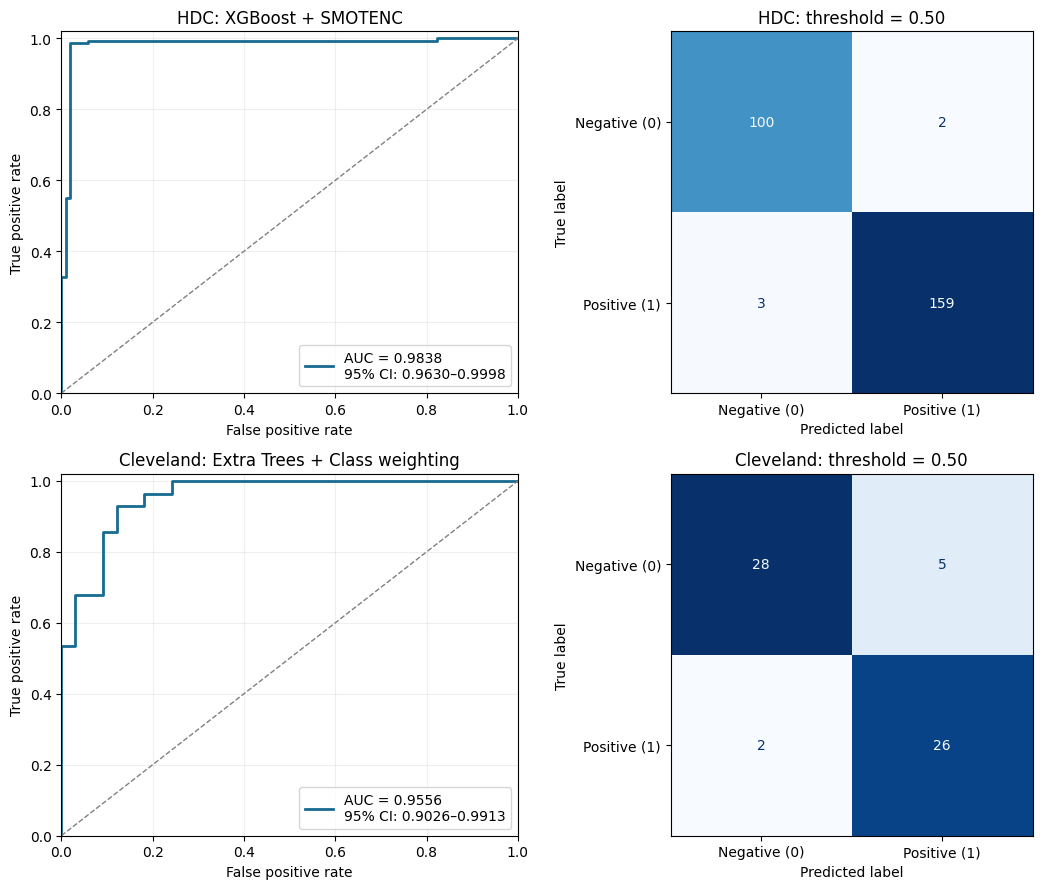

ROC curves and confusion matrices saved.


In [61]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

figure_dir = tuning_dir / "figures"
figure_dir.mkdir(exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

for row, dataset_name in enumerate(["HDC", "Cleveland"]):
    table = test_predictions[dataset_name]

    actual = table["Actual"].to_numpy()
    predicted = table["Predicted"].to_numpy()
    probabilities = table["Probability_class_1"].to_numpy()

    model_name, method = selection_details[dataset_name]

    # ROC curve
    fpr, tpr, _ = roc_curve(actual, probabilities)
    auc_value = roc_auc_score(actual, probabilities)

    auc_ci = test_confidence_intervals.loc[
        (test_confidence_intervals["Dataset"] == dataset_name)
        & (test_confidence_intervals["Metric"] == "ROC-AUC")
    ].iloc[0]

    ax = axes[row, 0]
    ax.plot(
        fpr, tpr,
        color="#176B91",
        linewidth=2,
        label=(
            f"AUC = {auc_value:.4f}\n"
            f"95% CI: {auc_ci['CI lower']:.4f}"
            f"–{auc_ci['CI upper']:.4f}"
        )
    )
    ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1)
    ax.set(
        xlabel="False positive rate",
        ylabel="True positive rate",
        title=f"{dataset_name}: {model_name} + {method}",
        xlim=(0, 1),
        ylim=(0, 1.02)
    )
    ax.legend(loc="lower right")
    ax.grid(alpha=0.2)

    # Confusion matrix: rows are actual, columns are predicted.
    matrix = confusion_matrix(actual, predicted, labels=[0, 1])

    ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Negative (0)", "Positive (1)"]
    ).plot(
        ax=axes[row, 1],
        cmap="Blues",
        colorbar=False,
        values_format="d"
    )
    axes[row, 1].set_title(
        f"{dataset_name}: threshold = {THRESHOLD:.2f}"
    )

fig.tight_layout()

fig.savefig(
    figure_dir / "selected_models_roc_confusion.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    figure_dir / "selected_models_roc_confusion.pdf",
    bbox_inches="tight"
)

plt.show()
print("ROC curves and confusion matrices saved.")

Calculating permutation importance: HDC...

HDC


,Feature,Mean_AUC_decrease,Shuffle_SD
7,troponin,0.35947,0.02473
6,kcm,0.15234,0.01709
2,impluse,0.00092,0.00126
0,age,0.00049,0.00045
5,glucose,0.00040,0.00112
4,pressurelow,-0.00016,0.00113
3,pressurehight,-0.00110,0.00205
1,gender,-0.00218,0.00169


Calculating permutation importance: Cleveland...

Cleveland


,Feature,Mean_AUC_decrease,Shuffle_SD
11,ca,0.07475,0.02396
2,cp,0.06176,0.01628
12,thal,0.03481,0.02016
8,exang,0.02760,0.01007
10,slope,0.02731,0.01732
1,sex,0.01310,0.01187
6,restecg,0.01093,0.00654
0,age,0.00523,0.00239
7,thalach,0.00509,0.00271
9,oldpeak,0.00498,0.00206


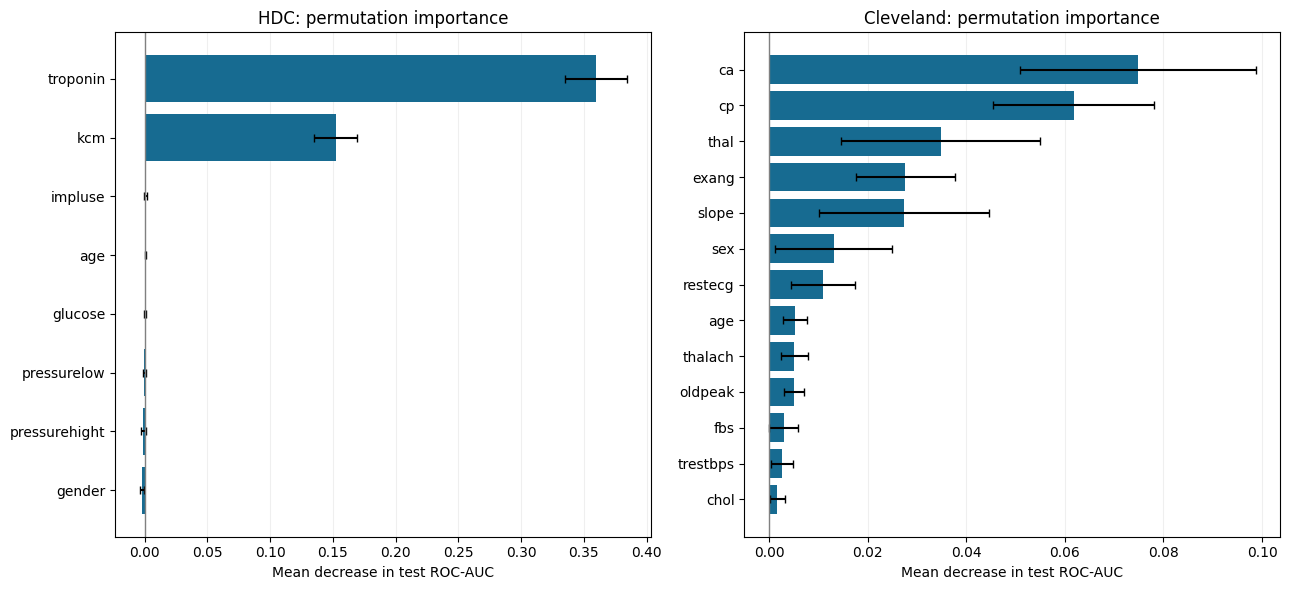

Permutation importance tables and figures saved.


In [62]:
from sklearn.inspection import permutation_importance

permutation_tables = {}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

for ax, dataset_name in zip(axes, ["HDC", "Cleveland"]):
    pipeline = selected_models[dataset_name]
    X_test, y_test = test_datasets[dataset_name]

    print(
        f"Calculating permutation importance: {dataset_name}...",
        flush=True
    )

    # Shuffle original columns before the fitted preprocessing steps.
    result = permutation_importance(
        estimator=pipeline,
        X=X_test,
        y=y_test,
        scoring="roc_auc",
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=1
    )

    importance_table = pd.DataFrame({
        "Feature": X_test.columns,
        "Mean_AUC_decrease": result.importances_mean,
        "Shuffle_SD": result.importances_std
    }).sort_values("Mean_AUC_decrease", ascending=False)

    permutation_tables[dataset_name] = importance_table

    importance_table.to_csv(
        tuning_dir / f"{dataset_name}_permutation_importance.csv",
        index=False
    )

    # Save individual shuffle results for reproducibility.
    pd.DataFrame(
        result.importances,
        index=X_test.columns,
        columns=[f"Shuffle_{i + 1}" for i in range(30)]
    ).to_csv(
        tuning_dir / f"{dataset_name}_permutation_repeats.csv",
        index_label="Feature"
    )

    print(f"\n{dataset_name}")
    display(importance_table.round(5))

    plot_table = importance_table.sort_values("Mean_AUC_decrease")

    ax.barh(
        plot_table["Feature"],
        plot_table["Mean_AUC_decrease"],
        xerr=plot_table["Shuffle_SD"],
        color="#176B91",
        capsize=3
    )
    ax.axvline(0, color="gray", linewidth=1)
    ax.set_title(f"{dataset_name}: permutation importance")
    ax.set_xlabel("Mean decrease in test ROC-AUC")
    ax.grid(axis="x", alpha=0.2)
    ax.set_axisbelow(True)

fig.tight_layout()

fig.savefig(
    figure_dir / "permutation_importance.png",
    dpi=300, bbox_inches="tight"
)
fig.savefig(
    figure_dir / "permutation_importance.pdf",
    bbox_inches="tight"
)

plt.show()
print("Permutation importance tables and figures saved.")

In [63]:
%pip install -q shap

import shap
from importlib.metadata import version

print("SHAP:", version("shap"))
print("XGBoost:", version("xgboost"))
print("scikit-learn:", version("scikit-learn"))
print("NumPy:", version("numpy"))

print("\nSHAP imported successfully.")

SHAP: 0.52.0
XGBoost: 3.4.1
scikit-learn: 1.6.1
NumPy: 2.1.3

SHAP imported successfully.



Calculating SHAP: HDC...


PermutationExplainer explainer: 265it [01:17,  3.07it/s]

Maximum reconstruction error: 0.00000000


,Feature,Mean_absolute_SHAP
7,troponin,0.37630
6,kcm,0.17501
1,gender,0.00423
3,pressurehight,0.00363
5,glucose,0.00212
2,impluse,0.00161
4,pressurelow,0.00159
0,age,0.00042


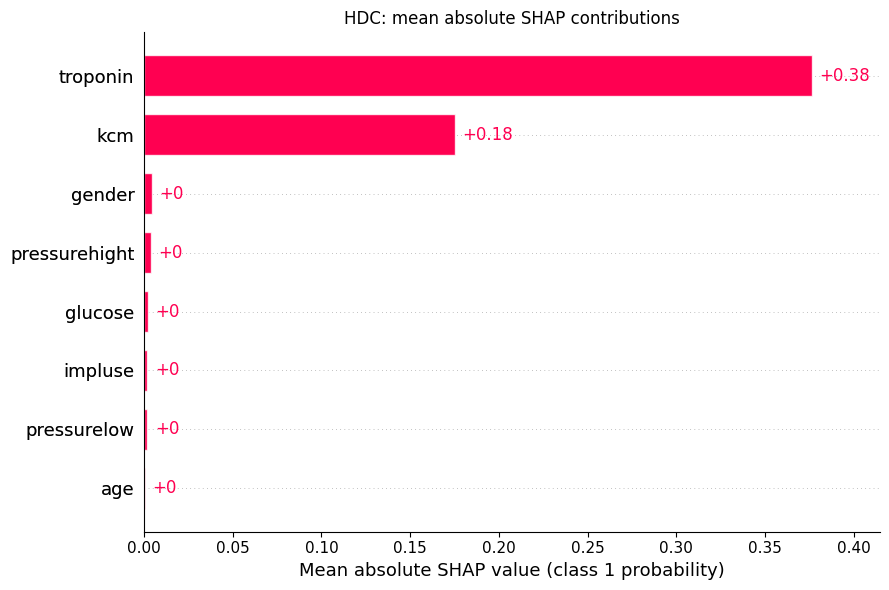


Calculating SHAP: Cleveland...


PermutationExplainer explainer: 62it [00:30,  1.33it/s]

Maximum reconstruction error: 0.00000000


,Feature,Mean_absolute_SHAP
11,ca,0.11909
12,thal,0.11502
2,cp,0.08550
10,slope,0.06399
1,sex,0.05244
8,exang,0.02804
6,restecg,0.01800
7,thalach,0.01132
0,age,0.01029
9,oldpeak,0.00971


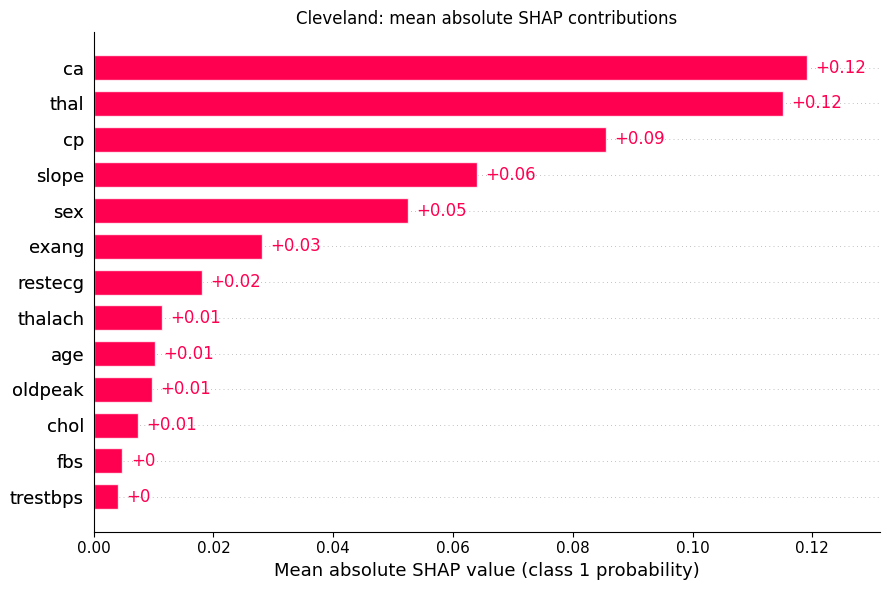


SHAP analysis completed. Models were not retrained.


In [64]:
# Explain each complete pipeline using its original input columns.
def make_probability_function(pipeline, columns):
    positive_column = list(pipeline.classes_).index(1)

    def predict_positive(values):
        frame = pd.DataFrame(values, columns=columns)
        return pipeline.predict_proba(frame)[:, positive_column]

    return predict_positive


shap_explanations = {}
shap_importance_tables = {}
shap_backgrounds = {}

for dataset_name in ["HDC", "Cleveland"]:
    print(f"\nCalculating SHAP: {dataset_name}...", flush=True)

    pipeline = selected_models[dataset_name]
    X_train = training_datasets[dataset_name][0]
    X_test, _ = test_datasets[dataset_name]
    columns = list(X_train.columns)

    # Use original training records, not synthetic SMOTENC records.
    background = X_train.sample(
        n=min(50, len(X_train)),
        random_state=RANDOM_STATE
    )
    shap_backgrounds[dataset_name] = background

    predict_positive = make_probability_function(pipeline, columns)

    masker = shap.maskers.Independent(
        background,
        max_samples=len(background)
    )

    explainer = shap.Explainer(
        predict_positive,
        masker=masker,
        algorithm="permutation",
        feature_names=columns,
        seed=RANDOM_STATE
    )

    # Budget for 20 forward/reverse permutation cycles per record.
    explanations = explainer(
        X_test,
        max_evals=20 * (2 * len(columns) + 1)
    )

    # Verify that contributions reconstruct model probabilities.
    probabilities = predict_positive(X_test)
    reconstructed = (
        np.asarray(explanations.base_values).reshape(-1)
        + explanations.values.sum(axis=1)
    )

    max_error = np.max(np.abs(probabilities - reconstructed))
    print(f"Maximum reconstruction error: {max_error:.8f}")

    assert np.allclose(
        probabilities, reconstructed, atol=1e-5, rtol=0
    ), "SHAP reconstruction check failed."

    shap_explanations[dataset_name] = explanations

    importance = pd.DataFrame({
        "Feature": columns,
        "Mean_absolute_SHAP": np.abs(
            explanations.values
        ).mean(axis=0)
    }).sort_values("Mean_absolute_SHAP", ascending=False)

    shap_importance_tables[dataset_name] = importance
    display(importance.round(5))

    importance.to_csv(
        tuning_dir / f"{dataset_name}_shap_importance.csv",
        index=False
    )

    contributions = pd.DataFrame(
        explanations.values,
        columns=columns,
        index=X_test.index
    )
    contributions.index.name = "Original_row_index"
    contributions["Base_probability"] = (
        np.asarray(explanations.base_values).reshape(-1)
    )
    contributions["Predicted_probability"] = probabilities

    contributions.to_csv(
        tuning_dir / f"{dataset_name}_shap_contributions.csv"
    )
    background.to_csv(
        tuning_dir / f"{dataset_name}_shap_background.csv",
        index_label="Original_row_index"
    )

    # Plot all original features.
    shap.plots.bar(
        explanations,
        max_display=len(columns),
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(9, 6)
    plt.title(f"{dataset_name}: mean absolute SHAP contributions")
    plt.xlabel("Mean absolute SHAP value (class 1 probability)")
    fig.tight_layout()

    for extension in ["png", "pdf"]:
        fig.savefig(
            figure_dir / f"{dataset_name}_shap_bar.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

print("\nSHAP analysis completed. Models were not retrained.")

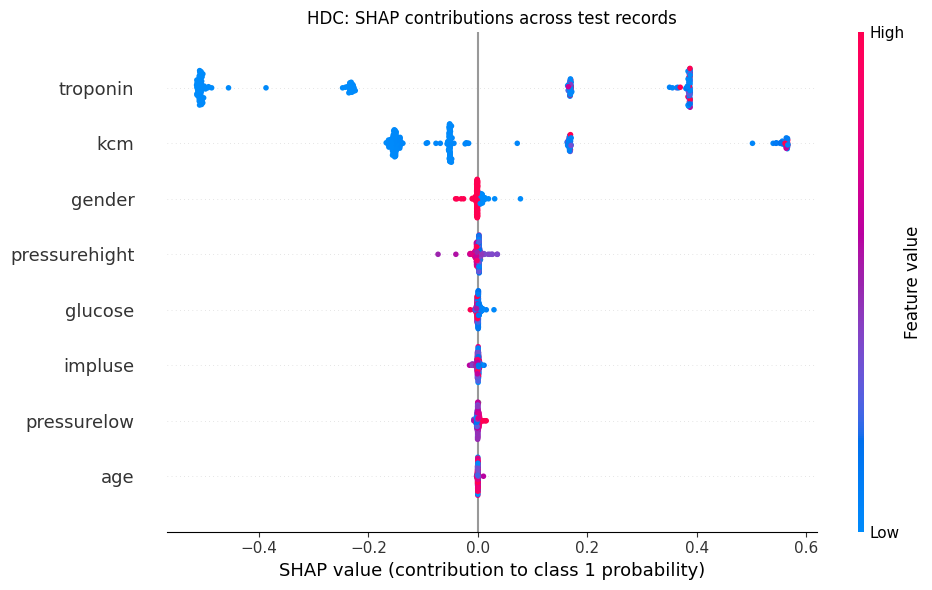

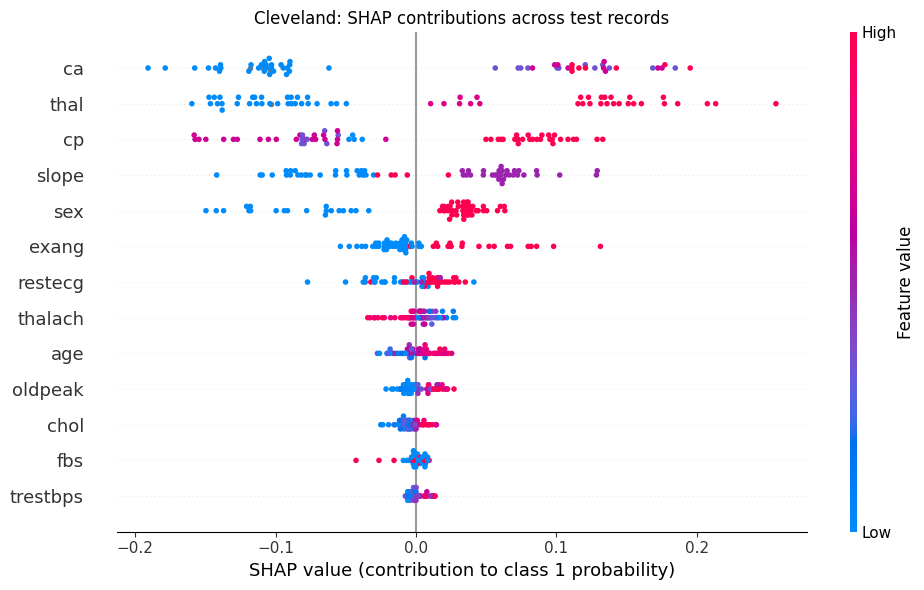

SHAP beeswarm plots saved.


In [65]:
# Each dot represents one held-out record.
# Positive SHAP: increases the model's class-1 probability.
# Negative SHAP: decreases it relative to the background value.

for dataset_name in ["HDC", "Cleveland"]:
    explanation = shap_explanations[dataset_name]

    shap.plots.beeswarm(
        explanation,
        max_display=len(explanation.feature_names),
        plot_size=(10, 6),
        show=False
    )

    fig = plt.gcf()
    plt.title(f"{dataset_name}: SHAP contributions across test records")
    plt.xlabel("SHAP value (contribution to class 1 probability)")
    fig.tight_layout()

    for extension in ["png", "pdf"]:
        fig.savefig(
            figure_dir / f"{dataset_name}_shap_beeswarm.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

print("SHAP beeswarm plots saved.")

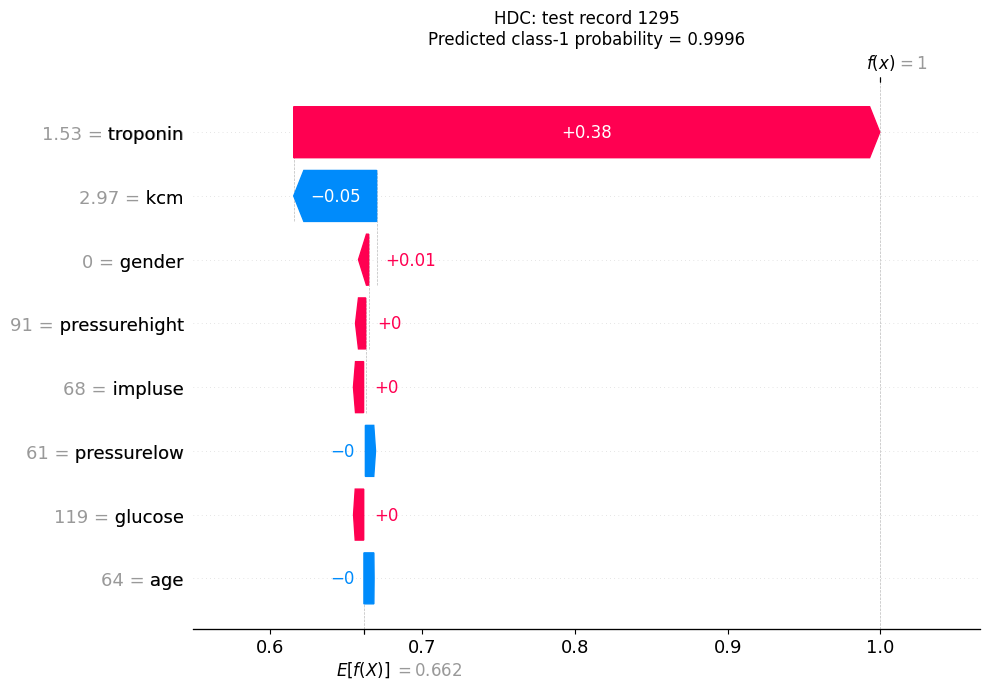

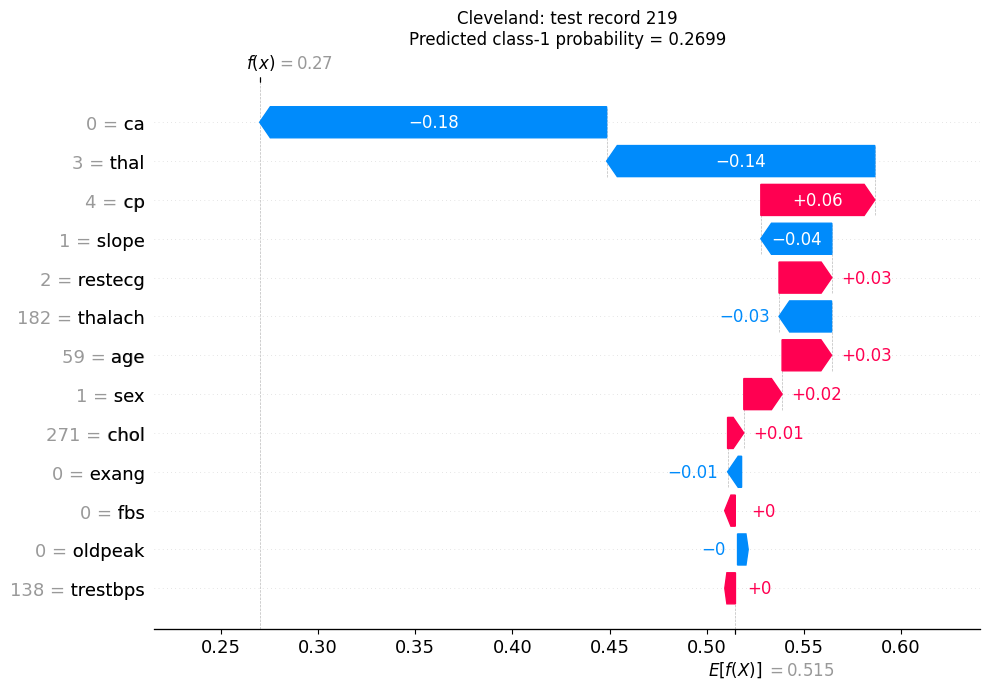

,Dataset,Original_row_index,Actual,Predicted,Base_probability,SHAP_sum,Predicted_probability
0,HDC,1295,1,1,0.66177,0.33784,0.99961
1,Cleveland,219,0,0,0.51481,-0.24495,0.26986


Individual SHAP explanations saved.


In [66]:
local_shap_records = []

for dataset_name in ["HDC", "Cleveland"]:
    X_test, y_test = test_datasets[dataset_name]
    explanation = shap_explanations[dataset_name]

    position = 0
    original_index = X_test.index[position]
    individual = explanation[position]

    base_probability = float(
        np.asarray(individual.base_values).reshape(-1)[0]
    )
    shap_sum = float(np.asarray(individual.values).sum())

    pipeline = selected_models[dataset_name]
    positive_column = list(pipeline.classes_).index(1)
    predicted_probability = float(
        pipeline.predict_proba(
            X_test.iloc[[position]]
        )[0, positive_column]
    )

    local_shap_records.append({
        "Dataset": dataset_name,
        "Original_row_index": original_index,
        "Actual": int(y_test.iloc[position]),
        "Predicted": int(predicted_probability >= 0.50),
        "Base_probability": base_probability,
        "SHAP_sum": shap_sum,
        "Predicted_probability": predicted_probability
    })

    shap.plots.waterfall(
        individual,
        max_display=len(X_test.columns),
        show=False
    )

    fig = plt.gcf()
    fig.set_size_inches(10, 7)
    plt.title(
        f"{dataset_name}: test record {original_index}\n"
        f"Predicted class-1 probability = "
        f"{predicted_probability:.4f}"
    )
    fig.tight_layout()

    for extension in ["png", "pdf"]:
        fig.savefig(
            figure_dir / f"{dataset_name}_shap_waterfall.{extension}",
            dpi=300,
            bbox_inches="tight"
        )

    plt.show()
    plt.close(fig)

local_shap_summary = pd.DataFrame(local_shap_records)
local_shap_summary.to_csv(
    tuning_dir / "local_shap_examples.csv",
    index=False
)

display(local_shap_summary.round(5))
print("Individual SHAP explanations saved.")

In [67]:
from pathlib import Path
from datetime import datetime, timezone
from zipfile import ZipFile, ZIP_DEFLATED
from importlib.metadata import version
from google.colab import files
import joblib
import json

# Preserve fitted models and computed explanations.
joblib.dump(
    {
        "selected_models": selected_models,
        "selection_details": selection_details,
        "test_predictions": test_predictions,
        "shap_explanations": shap_explanations,
        "shap_backgrounds": shap_backgrounds
    },
    tuning_dir / "selected_models_and_explanations.joblib"
)

metadata = {
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_state": RANDOM_STATE,
    "classification_threshold": 0.50,
    "test_sets_evaluated": True,
    "selection_metric": "Mean training cross-validation ROC-AUC",
    "selected_models": selection_details,
    "versions": {
        package: version(package)
        for package in [
            "numpy", "pandas", "scikit-learn",
            "xgboost", "catboost", "imbalanced-learn", "shap"
        ]
    }
}

with open(tuning_dir / "analysis_checkpoint_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Include earlier CV results and all current tuning/results files.
archive_path = Path("heart_disease_analysis_checkpoint.zip")

with ZipFile(archive_path, "w", ZIP_DEFLATED) as archive:
    for folder in [Path("cv_checkpoint"), Path(tuning_dir)]:
        if folder.exists():
            for path in sorted(folder.rglob("*")):
                if path.is_file():
                    archive.write(
                        path,
                        arcname=str(Path(folder.name) / path.relative_to(folder))
                    )

print(f"Checkpoint created: {archive_path.name}")
print(f"Size: {archive_path.stat().st_size / (1024 ** 2):.2f} MB")
files.download(str(archive_path))

Checkpoint created: heart_disease_analysis_checkpoint.zip
Size: 2.16 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
from sklearn.base import clone
from sklearn.model_selection import cross_validate

sensitivity_rows = []
sensitivity_fold_rows = []

# Copy the selected model's settings without changing the fitted model.
xgb_settings = clone(
    selected_models["HDC"].named_steps["model"]
)

feature_sets = {
    "All eight predictors": list(X_hdc_train.columns),
    "Without troponin and kcm": [
        col for col in X_hdc_train.columns
        if col not in ["troponin", "kcm"]
    ]
}

for analysis_name, columns in feature_sets.items():
    print(f"Running: {analysis_name}...", flush=True)

    numeric = [col for col in hdc_numeric if col in columns]
    categorical = [
        col for col in hdc_categorical if col in columns
    ]

    pipeline = make_smotenc_pipeline(
        numeric, categorical, xgb_settings
    )

    scores = cross_validate(
        pipeline,
        X_hdc_train[columns],
        y_hdc_train,
        cv=cv_splits["HDC"],
        scoring=scoring,
        n_jobs=1,
        error_score="raise"
    )

    summary = {
        "Analysis": analysis_name,
        "Predictors": len(columns)
    }

    for metric in scoring:
        values = scores[f"test_{metric}"]
        summary[f"{metric}_mean"] = values.mean()
        summary[f"{metric}_sd"] = values.std(ddof=1)

    sensitivity_rows.append(summary)

    for fold in range(len(cv_splits["HDC"])):
        sensitivity_fold_rows.append({
            "Analysis": analysis_name,
            "Fold": fold + 1,
            **{
                metric: scores[f"test_{metric}"][fold]
                for metric in scoring
            }
        })

hdc_sensitivity = pd.DataFrame(sensitivity_rows)
hdc_sensitivity_folds = pd.DataFrame(sensitivity_fold_rows)

hdc_sensitivity.to_csv(
    tuning_dir / "HDC_biomarker_sensitivity_summary.csv",
    index=False
)
hdc_sensitivity_folds.to_csv(
    tuning_dir / "HDC_biomarker_sensitivity_folds.csv",
    index=False
)

display(hdc_sensitivity[[
    "Analysis", "Predictors",
    "roc_auc_mean", "roc_auc_sd",
    "balanced_accuracy_mean", "recall_mean", "f1_mean"
]].round(4))

print("Completed using training data only.")
print("Existing selected models and test results are unchanged.")

Running: All eight predictors...
Running: Without troponin and kcm...


,Analysis,Predictors,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,recall_mean,f1_mean
0,All eight predictors,8,0.9973,0.0032,0.9881,0.9861,0.9899
1,Without troponin and kcm,6,0.6080,0.0328,0.5822,0.6559,0.6675


Completed using training data only.
Existing selected models and test results are unchanged.


In [69]:
cleaning_rows = []
cleaning_fold_rows = []

# Same training records and order; original measurements retained.
X_hdc_train_original = X_hdc.loc[X_hdc_train.index].copy()

assert X_hdc_train_original.index.equals(X_hdc_train.index)
assert y_hdc_train.index.equals(X_hdc_train.index)

cleaning_versions = {
    "Original measurements": X_hdc_train_original,
    "Flagged measurements set to missing": X_hdc_train
}

for analysis_name, X_version in cleaning_versions.items():
    print(f"Running: {analysis_name}...", flush=True)

    pipeline = make_smotenc_pipeline(
        hdc_numeric,
        hdc_categorical,
        clone(selected_models["HDC"].named_steps["model"])
    )

    scores = cross_validate(
        pipeline,
        X_version,
        y_hdc_train,
        cv=cv_splits["HDC"],
        scoring=scoring,
        n_jobs=1,
        error_score="raise"
    )

    row = {"Analysis": analysis_name}

    for metric in scoring:
        values = scores[f"test_{metric}"]
        row[f"{metric}_mean"] = values.mean()
        row[f"{metric}_sd"] = values.std(ddof=1)

    cleaning_rows.append(row)

    for fold in range(len(cv_splits["HDC"])):
        cleaning_fold_rows.append({
            "Analysis": analysis_name,
            "Fold": fold + 1,
            **{
                metric: scores[f"test_{metric}"][fold]
                for metric in scoring
            }
        })

cleaning_sensitivity = pd.DataFrame(cleaning_rows)

cleaning_sensitivity.to_csv(
    tuning_dir / "HDC_cleaning_sensitivity_summary.csv",
    index=False
)
pd.DataFrame(cleaning_fold_rows).to_csv(
    tuning_dir / "HDC_cleaning_sensitivity_folds.csv",
    index=False
)

display(cleaning_sensitivity[[
    "Analysis", "roc_auc_mean", "roc_auc_sd",
    "balanced_accuracy_mean", "recall_mean", "f1_mean"
]].round(4))

print("Completed using training data only.")
print("Existing selected models and test results are unchanged.")

Running: Original measurements...
Running: Flagged measurements set to missing...


,Analysis,roc_auc_mean,roc_auc_sd,balanced_accuracy_mean,recall_mean,f1_mean
0,Original measurements,0.9971,0.0035,0.9881,0.9861,0.9899
1,Flagged measurements set to missing,0.9973,0.0032,0.9881,0.9861,0.9899


Completed using training data only.
Existing selected models and test results are unchanged.


** Part 2 **

In [70]:
%pip install -q lime

In [71]:
# Correctly retrieve the HDC training objects
X_train_hdc, y_train_hdc, hdc_preprocessor = training_datasets["HDC"]

# Retrieve the test data
X_test_hdc, y_test_hdc = test_datasets["HDC"]

print("Training X shape:", X_train_hdc.shape)
print("Training y shape:", y_train_hdc.shape)

print("Test X shape:", X_test_hdc.shape)
print("Test y shape:", y_test_hdc.shape)

print("\nTraining features:")
print(list(X_train_hdc.columns))

print("\nSelected row 337:")
display(X_test_hdc.loc[[337]])

Training X shape: (1055, 8)
Training y shape: (1055,)
Test X shape: (264, 8)
Test y shape: (264,)

Training features:
['age', 'gender', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']

Selected row 337:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
Original_row_index,,,,,,,,
337,48,0,74.0,118.0,78.0,141.0,18.96,0.007


In [72]:
# STEP 25E: Diagnose feature variation for LIME

diagnostic = pd.DataFrame({
    "dtype": X_train_hdc.dtypes,
    "n_unique": X_train_hdc.nunique(),
    "min": X_train_hdc.min(),
    "max": X_train_hdc.max(),
    "mean": X_train_hdc.mean(),
    "std": X_train_hdc.std()
})

print("HDC training feature diagnostics:")
display(diagnostic)

print("\nFeatures with zero standard deviation:")
zero_std = diagnostic[diagnostic["std"] == 0]
display(zero_std)

print("\nMissing values:")
print(X_train_hdc.isna().sum())

HDC training feature diagnostics:


,dtype,n_unique,min,max,mean,std
age,int64,74,14.000,103.0,56.188626,13.759091
gender,int64,2,0.000,1.0,0.655924,0.475291
impluse,float64,78,20.000,135.0,75.893536,15.707788
pressurehight,float64,108,65.000,223.0,128.038241,26.011710
pressurelow,float64,71,38.000,128.0,71.893881,13.870461
glucose,float64,225,60.000,541.0,146.180758,74.805440
kcm,float64,601,0.321,300.0,13.386563,41.715045
troponin,float64,307,0.001,10.0,0.392627,1.226796



Features with zero standard deviation:


,dtype,n_unique,min,max,mean,std



Missing values:
age              0
gender           0
impluse          3
pressurehight    9
pressurelow      9
glucose          0
kcm              0
troponin         0
dtype: int64


In [73]:
# STEP 25F: Prepare an imputed copy for LIME only

X_train_lime = X_train_hdc.copy()
X_test_lime = X_test_hdc.copy()

# Median-impute only the continuous variables that contain missing values
continuous_features = [
    "age",
    "impluse",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin"
]

for col in continuous_features:
    median_value = X_train_lime[col].median()

    X_train_lime[col] = X_train_lime[col].fillna(median_value)
    X_test_lime[col] = X_test_lime[col].fillna(median_value)

print("Missing values in LIME training data:")
print(X_train_lime.isna().sum())

print("\nMissing values in LIME test data:")
print(X_test_lime.isna().sum())

print("\nShapes:")
print("LIME training:", X_train_lime.shape)
print("LIME test:", X_test_lime.shape)

print("\nRow 337:")
display(X_test_lime.loc[[337]])

Missing values in LIME training data:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
dtype: int64

Missing values in LIME test data:
age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
dtype: int64

Shapes:
LIME training: (1055, 8)
LIME test: (264, 8)

Row 337:


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
Original_row_index,,,,,,,,
337,48,0,74.0,118.0,78.0,141.0,18.96,0.007


In [74]:
from pathlib import Path
from lime.lime_tabular import LimeTabularExplainer
import numpy as np
import pandas as pd

# Retrieve existing fitted model and datasets.
hdc_model = selected_models["HDC"]
X_train_hdc, y_train_hdc, _ = training_datasets["HDC"]
X_test_hdc, y_test_hdc = test_datasets["HDC"]

feature_names = list(X_train_hdc.columns)
positive_column = list(hdc_model.classes_).index(1)
case_index = 337

# Prepare explanation data using training medians only.
X_train_lime = X_train_hdc.copy()
X_test_lime = X_test_hdc.copy()

for col in hdc_numeric:
    median = X_train_hdc[col].median()
    X_train_lime[col] = X_train_lime[col].fillna(median)
    X_test_lime[col] = X_test_lime[col].fillna(median)

# The specific patient record being explained (used by STEP 28/29 below).
selected_instance = X_test_lime.loc[case_index].copy()

gender_index = feature_names.index("gender")

lime_explainer = LimeTabularExplainer(
    training_data=X_train_lime.to_numpy(dtype=float),
    feature_names=feature_names,
    class_names=["Class 0", "Class 1"],
    categorical_features=[gender_index],
    categorical_names={gender_index: ["0", "1"]},
    mode="classification",
    discretize_continuous=True,
    random_state=RANDOM_STATE
)

def lime_predict(values):
    frame = pd.DataFrame(values, columns=feature_names)
    frame["gender"] = frame["gender"].round().astype(int)
    return hdc_model.predict_proba(frame)

lime_explanation = lime_explainer.explain_instance(
    data_row=X_test_lime.loc[case_index].to_numpy(dtype=float),
    predict_fn=lime_predict,
    labels=(positive_column,),
    num_features=len(feature_names),
    num_samples=5000
)

model_probability = float(
    hdc_model.predict_proba(
        X_test_hdc.loc[[case_index]]
    )[0, positive_column]
)

assert np.isclose(
    lime_explanation.predict_proba[positive_column],
    model_probability,
    atol=1e-6,
    rtol=0
), "The explanation input changed this record's prediction."

local_prediction = float(
    np.asarray(lime_explanation.local_pred).reshape(-1)[0]
)

fidelity = pd.DataFrame([{
    "Dataset": "HDC",
    "Original_row_index": case_index,
    "Model_probability": model_probability,
    "LIME_local_prediction": local_prediction,
    "Absolute_difference": abs(model_probability - local_prediction),
    "LIME_weighted_R2": float(lime_explanation.score)
}])

coefficients = pd.DataFrame(
    lime_explanation.as_list(label=positive_column),
    columns=["Feature_condition", "Local_surrogate_coefficient"]
)
coefficients.insert(0, "Original_row_index", case_index)

output_dir = Path(tuning_dir)
output_dir.mkdir(parents=True, exist_ok=True)

fidelity.to_csv(output_dir / "HDC_lime_fidelity.csv", index=False)
coefficients.to_csv(
    output_dir / "HDC_lime_coefficients.csv", index=False
)

display(fidelity.round(6))

for name in ["HDC_lime_fidelity.csv", "HDC_lime_coefficients.csv"]:
    path = output_dir / name
    assert path.is_file()
    print(f"Saved: {path.resolve()} ({path.stat().st_size} bytes)")

,Dataset,Original_row_index,Model_probability,LIME_local_prediction,Absolute_difference,LIME_weighted_R2
0,HDC,337,0.998808,0.676813,0.321995,0.420369


Saved: /content/tuning_results/HDC_lime_fidelity.csv (187 bytes)
Saved: /content/tuning_results/HDC_lime_coefficients.csv (443 bytes)


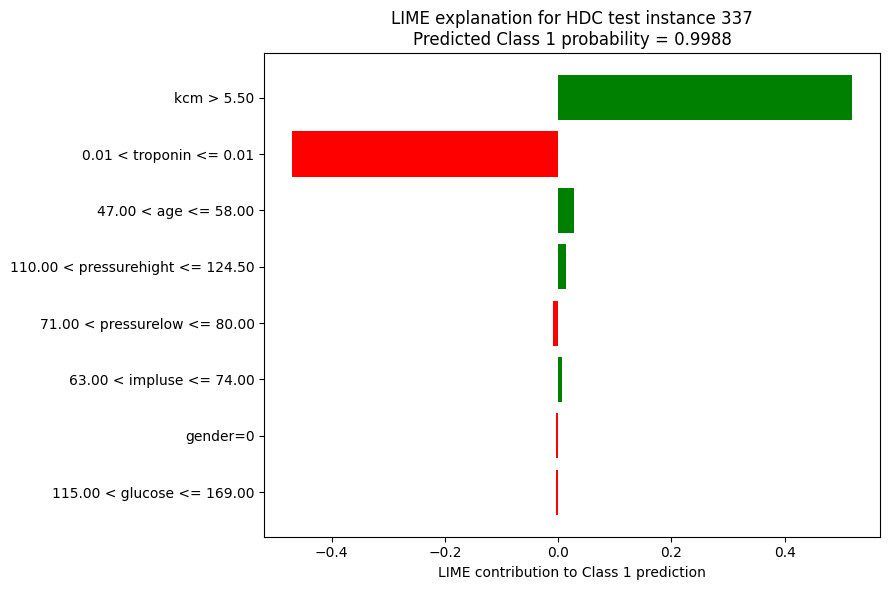

LIME figure saved successfully.


In [75]:
# STEP 26: Create and save publication LIME figure

import matplotlib.pyplot as plt

fig = lime_explanation.as_pyplot_figure(label=1)

fig.set_size_inches(9, 6)

plt.title(
    "LIME explanation for HDC test instance 337\n"
    "Predicted Class 1 probability = 0.9988"
)

plt.xlabel("LIME contribution to Class 1 prediction")

plt.tight_layout()

# Save publication-quality versions
fig.savefig(
    figure_dir / "HDC_LIME_instance_337.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    figure_dir / "HDC_LIME_instance_337.pdf",
    bbox_inches="tight"
)

plt.show()

print("LIME figure saved successfully.")

In [76]:
# STEP 28: Inspect exact LIME discretization values

print("Selected patient's troponin value:")
print(selected_instance["troponin"])

print("\nExact LIME explanation:")
for feature, contribution in lime_explanation.as_list(label=1):
    print(repr(feature), ":", contribution)

print("\nLIME discretizer names:")
for i, name in enumerate(lime_explainer.discretizer.names):
    print(feature_names[i], "->", name)

Selected patient's troponin value:
0.007

Exact LIME explanation:
'kcm > 5.50' : 0.5190173433173702
'0.01 < troponin <= 0.01' : -0.4692908653814473
'47.00 < age <= 58.00' : 0.027828214796491328
'110.00 < pressurehight <= 124.50' : 0.013752895997273208
'71.00 < pressurelow <= 80.00' : -0.008160346278538429
'63.00 < impluse <= 74.00' : 0.007012813360105993
'gender=0' : -0.004004390868134791
'115.00 < glucose <= 169.00' : -0.00398856460172095

LIME discretizer names:
age -> 0
gender -> 2
impluse -> 3
pressurehight -> 4
pressurelow -> 5
glucose -> 6
kcm -> 7


In [77]:
# STEP 29: Check exact quartile boundaries used for troponin

troponin_values = X_train_lime["troponin"].to_numpy()

q25, q50, q75 = np.percentile(
    troponin_values,
    [25, 50, 75]
)

print("Troponin quartile boundaries:")
print("25th percentile:", repr(q25))
print("50th percentile:", repr(q50))
print("75th percentile:", repr(q75))

print("\nSelected patient's troponin:")
print(repr(float(selected_instance["troponin"])))

print("\nRounded to 4 decimal places:")
print(f"Q25 = {q25:.4f}")
print(f"Q50 = {q50:.4f}")
print(f"Q75 = {q75:.4f}")
print(
    f"Patient troponin = "
    f"{float(selected_instance['troponin']):.4f}"
)

Troponin quartile boundaries:
25th percentile: np.float64(0.005)
50th percentile: np.float64(0.014)
75th percentile: np.float64(0.093)

Selected patient's troponin:
0.007

Rounded to 4 decimal places:
Q25 = 0.0050
Q50 = 0.0140
Q75 = 0.0930
Patient troponin = 0.0070


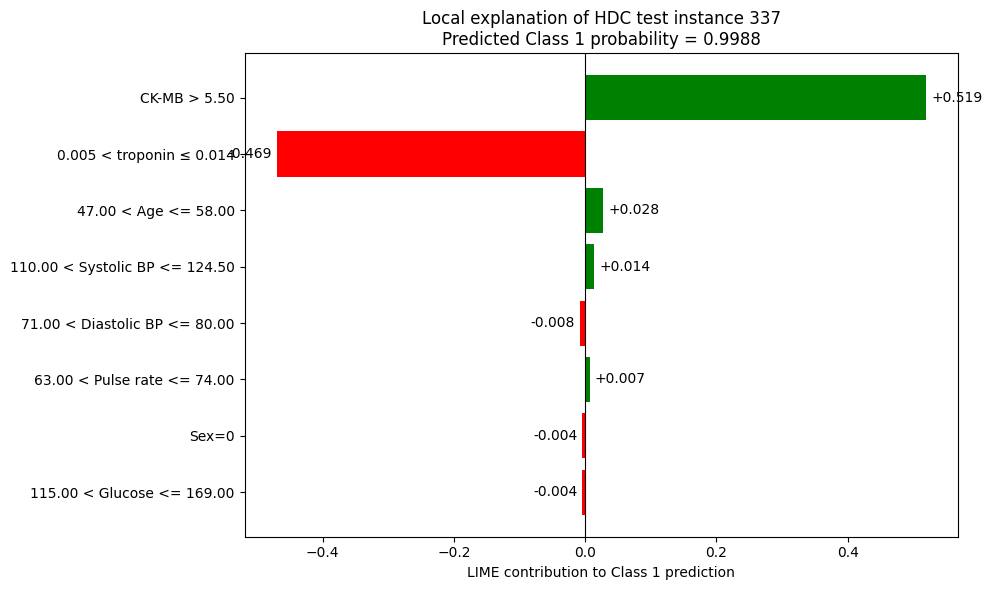

Final LIME figure saved.


In [78]:
# STEP 30: Create final publication-quality LIME figure

import matplotlib.pyplot as plt
import pandas as pd

# Use the existing LIME results — NO recalculation
lime_results = lime_explanation.as_list(label=1)

# Replace only the misleading rounded troponin label
clean_results = []

for label, contribution in lime_results:

    if "troponin" in label:
        label = "0.005 < troponin ≤ 0.014"

    # Improve variable names for publication
    label = label.replace("kcm", "CK-MB")
    label = label.replace("pressurehight", "Systolic BP")
    label = label.replace("pressurelow", "Diastolic BP")
    label = label.replace("impluse", "Pulse rate")
    label = label.replace("glucose", "Glucose")
    label = label.replace("age", "Age")
    label = label.replace("gender", "Sex")

    clean_results.append((label, contribution))


# Convert to dataframe
lime_plot = pd.DataFrame(
    clean_results,
    columns=["Feature", "Contribution"]
)

# Reverse order for horizontal plot
lime_plot = lime_plot.iloc[::-1]


# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "green" if value > 0 else "red"
    for value in lime_plot["Contribution"]
]

bars = ax.barh(
    lime_plot["Feature"],
    lime_plot["Contribution"],
    color=colors
)

# Zero reference line
ax.axvline(
    0,
    color="black",
    linewidth=0.8
)

ax.set_xlabel(
    "LIME contribution to Class 1 prediction"
)

ax.set_title(
    "Local explanation of HDC test instance 337\n"
    "Predicted Class 1 probability = 0.9988"
)

# Add contribution values
for bar, value in zip(
    bars,
    lime_plot["Contribution"]
):

    y = bar.get_y() + bar.get_height() / 2

    if value >= 0:
        ax.text(
            value + 0.008,
            y,
            f"+{value:.3f}",
            va="center"
        )
    else:
        ax.text(
            value - 0.008,
            y,
            f"{value:.3f}",
            va="center",
            ha="right"
        )

plt.tight_layout()

# Save
fig.savefig(
    figure_dir / "HDC_LIME_instance_337_FINAL.png",
    dpi=300,
    bbox_inches="tight"
)

fig.savefig(
    figure_dir / "HDC_LIME_instance_337_FINAL.pdf",
    bbox_inches="tight"
)

plt.show()

print("Final LIME figure saved.")

In [79]:
# STEP 32: Create summary table for explainability results

explainability_summary = pd.DataFrame({
    "Dataset": [
        "HDC", "HDC",
        "Cleveland", "Cleveland", "Cleveland"
    ],

    "Feature": [
        "Troponin",
        "CK-MB",
        "ca",
        "thal",
        "cp"
    ],

    "Mean_absolute_SHAP": [
        0.37630,
        0.17501,
        0.11909,
        0.11502,
        0.08550
    ],

    "Permutation_AUC_decrease": [
        0.35947,
        0.15234,
        0.07475,
        0.03481,
        0.06176
    ]
})

display(explainability_summary)

explainability_summary.to_csv(
    tuning_dir / "explainability_summary.csv",
    index=False
)

print("Explainability summary saved.")

,Dataset,Feature,Mean_absolute_SHAP,Permutation_AUC_decrease
0,HDC,Troponin,0.37630,0.35947
1,HDC,CK-MB,0.17501,0.15234
2,Cleveland,ca,0.11909,0.07475
3,Cleveland,thal,0.11502,0.03481
4,Cleveland,cp,0.08550,0.06176


Explainability summary saved.


In [80]:
# STEP 34: Examine HDC biomarkers by target class

hdc_check = X_train_hdc.copy()
hdc_check["target"] = y_train_hdc

print("Target class counts:")
print(hdc_check["target"].value_counts().sort_index())

print("\nTroponin by target class:")
display(
    hdc_check.groupby("target")["troponin"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

print("\nCK-MB (kcm) by target class:")
display(
    hdc_check.groupby("target")["kcm"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(4)
)

print("\nProportion with troponin > 0.014 by target:")
print(
    hdc_check.assign(
        troponin_high=hdc_check["troponin"] > 0.014
    )
    .groupby("target")["troponin_high"]
    .mean()
    .round(4)
)

print("\nProportion with CK-MB > 5.50 by target:")
print(
    hdc_check.assign(
        ckmb_high=hdc_check["kcm"] > 5.50
    )
    .groupby("target")["ckmb_high"]
    .mean()
    .round(4)
)

Target class counts:
target
0    407
1    648
Name: count, dtype: int64

Troponin by target class:


,count,mean,median,min,max
target,,,,,
0,407,0.0310,0.006,0.001,10.0
1,648,0.6197,0.049,0.003,10.0



CK-MB (kcm) by target class:


,count,mean,median,min,max
target,,,,,
0,407,2.5550,2.330,0.321,6.27
1,648,20.1897,3.505,0.353,300.00



Proportion with troponin > 0.014 by target:
target
0    0.0025
1    0.8025
Name: troponin_high, dtype: float64

Proportion with CK-MB > 5.50 by target:
target
0    0.0418
1    0.3812
Name: ckmb_high, dtype: float64


In [81]:
# STEP 35: Cross-tabulation of troponin threshold and target

hdc_check["troponin_high"] = (
    hdc_check["troponin"] > 0.014
).astype(int)

cross_tab = pd.crosstab(
    hdc_check["troponin_high"],
    hdc_check["target"],
    margins=True
)

print("Troponin threshold (> 0.014) versus target:")
display(cross_tab)

# Conditional percentages
row_percent = pd.crosstab(
    hdc_check["troponin_high"],
    hdc_check["target"],
    normalize="index"
) * 100

print("\nRow percentages (%):")
display(row_percent.round(2))

# Simple agreement between threshold and target
agreement = (
    hdc_check["troponin_high"] ==
    hdc_check["target"]
).mean()

print(
    "\nAgreement between troponin > 0.014 "
    "and target:",
    f"{agreement:.4f} ({agreement*100:.2f}%)"
)

Troponin threshold (> 0.014) versus target:


target,0,1,All
troponin_high,,,
0,406,128,534
1,1,520,521
All,407,648,1055



Row percentages (%):


target,0,1
troponin_high,,
0,76.03,23.97
1,0.19,99.81



Agreement between troponin > 0.014 and target: 0.8777 (87.77%)


In [82]:
# STEP 36: Search notebook variables for possible dataset/source information

for name, value in globals().copy().items():
    try:
        text = str(value)
        if (
            "kaggle" in text.lower()
            or "heart attack" in text.lower()
            or "heart_attack" in text.lower()
        ):
            if len(text) < 1000:
                print(name, "=", text)
    except:
        pass

_i41 = # STEP 36: Search notebook variables for possible dataset/source information

for name, value in globals().copy().items():
    try:
        text = str(value)
        if (
            "kaggle" in text.lower()
            or "heart attack" in text.lower()
            or "heart_attack" in text.lower()
        ):
            if len(text) < 1000:
                print(name, "=", text)
    except:
        pass
text = # STEP 36: Search notebook variables for possible dataset/source information

for name, value in globals().copy().items():
    try:
        text = str(value)
        if (
            "kaggle" in text.lower()
            or "heart attack" in text.lower()
            or "heart_attack" in text.lower()
        ):
            if len(text) < 1000:
                print(name, "=", text)
    except:
        pass
_i82 = # STEP 36: Search notebook variables for possible dataset/source information

for name, value in globals().copy().items():
    try:
        text = str(value)
     

**Final results export (corrected position).** This cell was moved from its original position (between the LIME placeholder-check cells and the actual LIME computation) to the end of the notebook, so it now runs after the LIME explanation has been generated. In the original ordering it ran too early and its export_status.json incorrectly reported HDC_lime_fidelity.csv and HDC_lime_coefficients.csv as missing. Run the full notebook top to bottom in one session before running this cell.

In [83]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
from google.colab import files
import json

results_folder = Path(tuning_dir)

if not results_folder.is_dir():
    raise FileNotFoundError(
        f"Results folder not found: {results_folder.resolve()}"
    )

expected_files = [
    "HDC_biomarker_sensitivity_summary.csv",
    "HDC_biomarker_sensitivity_folds.csv",
    "HDC_cleaning_sensitivity_summary.csv",
    "HDC_cleaning_sensitivity_folds.csv",
    "HDC_lime_fidelity.csv",
    "HDC_lime_coefficients.csv"
]

missing = [
    name for name in expected_files
    if not (results_folder / name).is_file()
]

archive_path = Path("heart_disease_analysis_checkpoint_updated.zip")

with ZipFile(archive_path, "w", ZIP_DEFLATED) as archive:
    for folder in [Path("cv_checkpoint"), results_folder]:
        if folder.is_dir():
            for path in sorted(folder.rglob("*")):
                if path.is_file():
                    archive.write(
                        path,
                        arcname=str(
                            Path(folder.name) / path.relative_to(folder)
                        )
                    )

    archive.writestr(
        "export_status.json",
        json.dumps({
            "complete": len(missing) == 0,
            "missing_expected_files": missing
        }, indent=2)
    )

print("Results folder:", results_folder.resolve())
print("Missing files:", missing)
print("Available results archived successfully.")

files.download(str(archive_path))

Results folder: /content/tuning_results
Missing files: []
Available results archived successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>